In [1]:
#You can use this chunk of code to setup different directory
import os

# Print the current working directory
print("Current Working Directory: ", os.getcwd())

# Change the directory
os.chdir('/group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell')

# Print the new working directory to verify the change
print("New Working Directory: ", os.getcwd())

Current Working Directory:  /group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell
New Working Directory:  /group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell


In [2]:
#Import any relevant librairies
import anndata
import anndata2ri
import gc
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, r
import scanpy as sc
import scipy as sp
import seaborn as sns
from rpy2.robjects.conversion import localconverter

During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


In [3]:
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

ro.r('Sys.setlocale("LC_ALL", "C")') 

/tmp/abso493b/5104518/ipykernel_116709/1902947678.py:2: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


array(['LC_CTYPE=C;LC_NUMERIC=C;LC_TIME=C;LC_COLLATE=C;LC_MONETARY=C;LC_MESSAGES=en_US.UTF-8;LC_PAPER=en_US.UTF-8;LC_NAME=C;LC_ADDRESS=C;LC_TELEPHONE=C;LC_MEASUREMENT=en_US.UTF-8;LC_IDENTIFICATION=C'],
      dtype='<U190')

In [4]:
%%R

# Load necessary libraries
library(Seurat)
library(ggplot2)
library(magrittr)
library(dplyr)
library(patchwork)
library(SoupX)
library(dsb)
library(BuenColors)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Loading required package: SeuratObject
Loading required package: sp

Attaching package: 'SeuratObject'

The following objects are masked from 'package:base':

    intersect, t


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: MASS

Attaching package: 'MASS'

The following object is masked from 'package:patchwork':

    area

The following object is masked from 'package:dplyr':

    select



In [6]:
%%R
remotes::install_github("bnprks/BPCells/r")

These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

 1: All                                 
 2: CRAN packages only                  
 3: None                                
 4: rlang     (1.1.5   -> 1.1.6 ) [CRAN]
 5: cli       (3.6.3   -> 3.6.5 ) [CRAN]
 6: scales    (1.3.0   -> 1.4.0 ) [CRAN]
 7: cpp11     (0.5.1   -> 0.5.2 ) [CRAN]
 8: utf8      (1.2.4   -> 1.2.6 ) [CRAN]
 9: pillar    (1.10.1  -> 1.11.1) [CRAN]
10: magrittr  (2.0.3   -> 2.0.4 ) [CRAN]
11: bit       (4.5.0.1 -> 4.6.0 ) [CRAN]
12: tzdb      (0.4.0   -> 0.5.0 ) [CRAN]
13: tibble    (3.2.1   -> 3.3.0 ) [CRAN]
14: hms       (1.1.3   -> 1.1.4 ) [CRAN]
15: stringi   (1.8.4   -> 1.8.7 ) [CRAN]
16: generics  (0.1.3   -> 0.1.4 ) [CRAN]
17: Rcpp      (1.0.14  -> 1.1.0 ) [CRAN]
18: ggplot2   (3.5.1   -> 4.0.0 ) [CRAN]
19: vroom     (1.6.5   -> 1.6.6 ) [CRAN]
20: stringr   (1.5.1   -> 1.5.2 ) [CRAN]
21: purrr     (1.0.4   -> 1.1.0 ) [CRAN]
22: patchwork

Enter one or more numbers, or an empty line to skip updates:  3


-- R CMD build -----------------------------------------------------------------
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
* checking for file '/tmp/abso493b/4755928/Rtmprkngqv/remotes199321bd2fc22/bnprks-BPCells-93f16ff/r/DESCRIPTION' ... OK
* preparing 'BPCells':
* checking DESCRIPTION meta-information ... OK
* cleaning src
* running 'cleanup'
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building 'BPCells_0.3.1.tar.gz'



During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
* installing *source* package 'BPCells' ...
** using staged installation


Recording install count metrics
Testing hdf5 by compiling example program...
Found working hdf5
HDF5_CFLAGS=''
HDF5_LIBS='-lhdf5'

Testing C++17 filesystem feature support...
Testing availability of highway SIMD library...
Highway not found or unusable

Building highway SIMD library from source


...

During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location


During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


** testing if installed package keeps a record of temporary installation path
* DONE (BPCells)


Installing package into '/home/crtd_sieweke/abso493b/R/x86_64-conda-linux-gnu-library/4.3'
(as 'lib' is unspecified)


In [7]:
%%R
devtools::install_github('cole-trapnell-lab/monocle3')

These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

 1: All                                             
 2: CRAN packages only                              
 3: None                                            
 4: speedglm    (0.3-5     -> ca34b4e53...) [GitHub]
 5: rlang       (1.1.5     -> 1.1.6       ) [CRAN]  
 6: cli         (3.6.3     -> 3.6.5       ) [CRAN]  
 7: scales      (1.3.0     -> 1.4.0       ) [CRAN]  
 8: utf8        (1.2.4     -> 1.2.6       ) [CRAN]  
 9: pillar      (1.10.1    -> 1.11.1      ) [CRAN]  
10: magrittr    (2.0.3     -> 2.0.4       ) [CRAN]  
11: stringi     (1.8.4     -> 1.8.7       ) [CRAN]  
12: tibble      (3.2.1     -> 3.3.0       ) [CRAN]  
13: generics    (0.1.3     -> 0.1.4       ) [CRAN]  
14: Rcpp        (1.0.14    -> 1.1.0       ) [CRAN]  
15: RCurl       (1.98-1.16 -> 1.98-1.17   ) [CRAN]  
16: units       (0.8-5     -> 1.0-0       ) [CRAN]  
17: s2          (1.1.7    

Enter one or more numbers, or an empty line to skip updates:  3


During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
* installing *source* package 'tweenr' ...
** package 'tweenr' successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: 'x86_64-conda-linux-gnu-cc (conda-forge gcc 14.2.0-1) 14.2.0'
using C++ compiler: 'x86_64-conda-linux-gnu-c++ (conda-forge gcc 14.2.0-1) 14.2.0'


x86_64-conda-linux-gnu-c++ -std=gnu++17 -I"/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/R/include" -DNDEBUG  -I'/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/R/library/cpp11/include' -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/include -I/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/include -Wl,-rpath-link,/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib    -fpic  -fvisibility-inlines-hidden  -fmessage-length=0 -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/include -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/r-base-split_1734346517311/work=/usr/local/src/conda/r-base-4.3.3 -fdebug-prefix-map=/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test=/usr/local/src/conda-prefix  -c along.cpp -o along.o
x86_64-conda-linux-gnu-c++ -std=gnu++

installing to /home/crtd_sieweke/abso493b/R/x86_64-conda-linux-gnu-library/4.3/00LOCK-tweenr/00new/tweenr/libs
** R
** byte-compile and prepare package for lazy loading


...

During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location


During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


** testing if installed package keeps a record of temporary installation path
* DONE (monocle3)


Installing 4 packages: tweenr, distributional, ggforce, ggdist
Installing packages into '/home/crtd_sieweke/abso493b/R/x86_64-conda-linux-gnu-library/4.3'
(as 'lib' is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/tweenr_2.0.3.tar.gz'
Content type 'application/x-gzip' length 584998 bytes (571 KB)
downloaded 571 KB

trying URL 'https://cloud.r-project.org/src/contrib/distributional_0.5.0.tar.gz'
Content type 'application/x-gzip' length 107440 bytes (104 KB)
downloaded 104 KB

trying URL 'https://cloud.r-project.org/src/contrib/ggforce_0.5.0.tar.gz'
Content type 'application/x-gzip' length 906529 bytes (885 KB)
downloaded 885 KB

trying URL 'https://cloud.r-project.org/src/contrib/ggdist_3.3.3.tar.gz'
Content type 'application/x-gzip' length 1777619 bytes (1.7 MB)
downloaded 1.7 MB


The downloaded source packages are in
	'/tmp/abso493b/4755928/Rtmprkngqv/downloaded_packages'
Installing package into '/home/crtd_sieweke/abso493b/R/x86_64-conda-linux-gnu-library/4.3'
(as

In [8]:
%%R
devtools::install_github("jinworks/CellChat")

These packages have more recent versions available.
It is recommended to update all of them.
Which would you like to update?

 1: All                                     
 2: CRAN packages only                      
 3: None                                    
 4: rlang        (1.1.5   -> 1.1.6  ) [CRAN]
 5: fs           (1.6.5   -> 1.6.6  ) [CRAN]
 6: cli          (3.6.3   -> 3.6.5  ) [CRAN]
 7: sass         (0.4.9   -> 0.4.10 ) [CRAN]
 8: mime         (0.12    -> 0.13   ) [CRAN]
 9: jsonlite     (1.9.0   -> 2.0.0  ) [CRAN]
10: Rcpp         (1.0.14  -> 1.1.0  ) [CRAN]
11: magrittr     (2.0.3   -> 2.0.4  ) [CRAN]
12: later        (1.4.1   -> 1.4.4  ) [CRAN]
13: promises     (1.3.2   -> 1.3.3  ) [CRAN]
14: utf8         (1.2.4   -> 1.2.6  ) [CRAN]
15: pillar       (1.10.1  -> 1.11.1 ) [CRAN]
16: tibble       (3.2.1   -> 3.3.0  ) [CRAN]
17: generics     (0.1.3   -> 0.1.4  ) [CRAN]
18: stringi      (1.8.4   -> 1.8.7  ) [CRAN]
19: cpp11        (0.5.1   -> 0.5.2  ) [CRAN]
20: stringr      (1

Enter one or more numbers, or an empty line to skip updates:  3


-- R CMD build -----------------------------------------------------------------
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
* checking for file '/tmp/abso493b/4755928/Rtmprkngqv/remotes199327e337fd8/jinworks-CellChat-623f48f/DESCRIPTION' ... OK
* preparing 'CellChat':
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building 'CellChat_2.2.0.tar.gz'



During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
* installing *source* package 'CellChat' ...
** using staged installation
** libs
using C++ compiler: 'x86_64-conda-linux-gnu-c++ (conda-forge gcc 14.2.0-1) 14.2.0'


x86_64-conda-linux-gnu-c++ -std=gnu++17 -I"/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/R/include" -DNDEBUG  -I'/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/R/library/Rcpp/include' -I'/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/R/library/RcppEigen/include' -DNDEBUG -D_FORTIFY_SOURCE=2 -O2 -isystem /home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/include -I/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/include -Wl,-rpath-link,/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib    -fpic  -fvisibility-inlines-hidden  -fmessage-length=0 -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/include -fdebug-prefix-map=/home/conda/feedstock_root/build_artifacts/r-base-split_1734346517311/work=/usr/local/src/conda/r-base-4.3.3 -fdebug-prefix-map=/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test

...

During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location


During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


** testing if installed package keeps a record of temporary installation path
* DONE (CellChat)


Installing package into '/home/crtd_sieweke/abso493b/R/x86_64-conda-linux-gnu-library/4.3'
(as 'lib' is unspecified)


In [5]:
%%R
library(monocle3)
library(CellChat)
Integrated_sc<-readRDS("/group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell/All_Javi_seurat_CCA_processed_singleR_replicatecombined.RDS")
Unintegrated_sc<-readRDS("/group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell/All_Javi_seurat_processed_singleR_replicatecombined.RDS")
                                                                      

Loading required package: Biobase
Loading required package: BiocGenerics

Attaching package: 'BiocGenerics'

The following objects are masked from 'package:dplyr':

    combine, intersect, setdiff, union

The following object is masked from 'package:SeuratObject':

    intersect

The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs

The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'ci

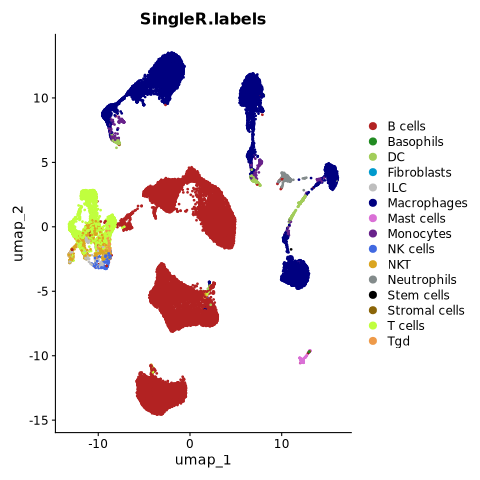

In [6]:
%%R

cols = c("firebrick", "forestgreen", "darkolivegreen3", "deepskyblue3", "gray", "navy", "orchid", "darkorchid4","royalblue", "goldenrod", "azure4", "black", "darkgoldenrod4", "olivedrab1", "tan2","azure3", "forestgreen", "salmon")
p1<-DimPlot(
  Unintegrated_sc,
  group.by = 'SingleR.labels',
  label.size = 3,
  pt.size = 0.5,
  cols = cols
)

p1

In [9]:
%%R
Macrophages_unitegrated <- subset(Unintegrated_sc, subset = SingleR.labels %in% c("Macrophages"))
Macrophages_integrated <- subset(Integrated_sc, subset = SingleR.labels %in% c("Macrophages"))


Tcell_unitegrated <- subset(Unintegrated_sc, subset = SingleR.labels %in% c("T cells","Tgd","NKT"))
Tcell_integrated <- subset(Integrated_sc, subset = SingleR.labels %in% c("T cells","Tgd","NKT"))

Macrophages_integrated@meta.data <- Macrophages_integrated@meta.data %>%
  mutate(
    samplid_combined = case_when(
      grepl("^LPS_24H", sampleid) ~ "LPS_24H",
      grepl("^LPS_4H",  sampleid) ~ "LPS_4H",
      grepl("^LPS_1H",  sampleid) ~ "LPS_1H",
      grepl("^NT_0H",   sampleid) ~ "NT_0H",
      TRUE ~ NA_character_
    )
  )

Macrophages_integrated@meta.data$samplid_combined <- factor(
  Macrophages_integrated@meta.data$samplid_combined,
  levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
)

Tcell_integrated@meta.data <- Tcell_integrated@meta.data %>%
  mutate(
    samplid_combined = case_when(
      grepl("^LPS_24H", sampleid) ~ "LPS_24H",
      grepl("^LPS_4H",  sampleid) ~ "LPS_4H",
      grepl("^LPS_1H",  sampleid) ~ "LPS_1H",
      grepl("^NT_0H",   sampleid) ~ "NT_0H",
      TRUE ~ NA_character_
    )
  )

Tcell_integrated@meta.data$samplid_combined <- factor(
   Tcell_integrated@meta.data$samplid_combined,
  levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
)

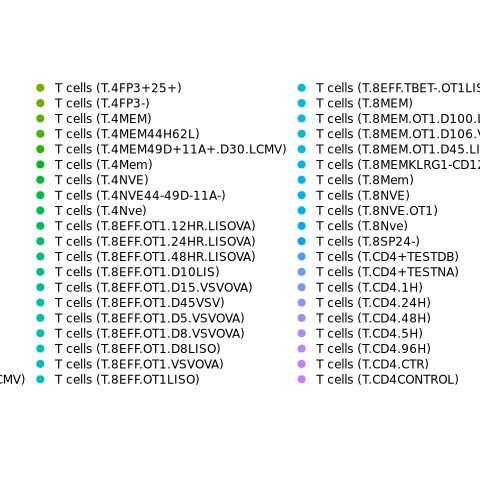

In [10]:
%%R
p1<-DimPlot(
  Tcell_unitegrated,
  group.by = 'SingleR.labels.fine',
  label.size = 3,
  pt.size = 0.5,
)

ggsave(
  filename = "Tcells_additonal_singlecell.pdf",
  plot = p1,
  width = 20,
  height = 6
)

p1

In [26]:
%%R

p<-FeaturePlot(Tcell_integrated, features = c("Cdkn"), reduction ="umap.cca", split.by = "samplid_combined")
ggsave(
  filename = "Tcells_singlecell_activation_Ki67_additional.pdf",
  plot = p,
  width = 20,
  height = 6
)

p

Error in `FeaturePlot()`:
! None of the requested features were found: Ki67 in slot  data
Run `rlang::last_trace()` to see where the error occurred.
Warning message:
The following requested variables were not found: Ki67
Error in FeaturePlot(Tcell_integrated, features = c("Ki67"), reduction = "umap.cca",  :


RInterpreterError: Failed to parse and evaluate line '\np<-FeaturePlot(Tcell_integrated, features = c("Ki67"), reduction ="umap.cca", split.by = "samplid_combined")\nggsave(\n  filename = "Tcells_singlecell_activation_Ki67_additional.pdf",\n  plot = p,\n  width = 20,\n  height = 6\n)\n\np\n'.
R error message: 'Error in FeaturePlot(Tcell_integrated, features = c("Ki67"), reduction = "umap.cca",  :'
R stdout:
Warning message:
The following requested variables were not found: Ki67

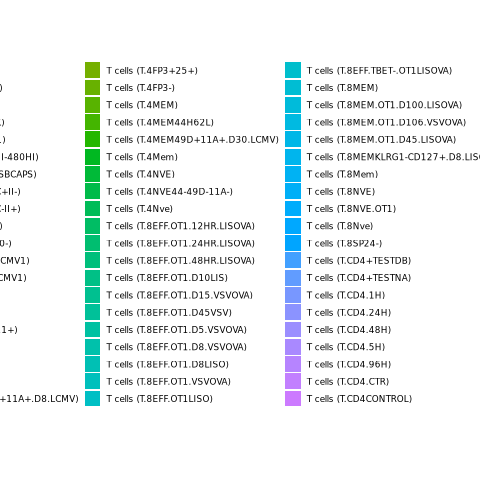

In [13]:
%%R

library(dplyr)
Tcell_integrated@meta.data$SingleR.labels.fine <-Tcell_unitegrated@meta.data$SingleR.labels.fine

prop_trm <- Tcell_integrated@meta.data %>%
  dplyr::count(samplid_combined, SingleR.labels.fine) %>%
  dplyr::group_by(samplid_combined) %>%
  dplyr::mutate(frac = n / sum(n))

library(ggplot2)

p1<-ggplot(prop_trm,
       aes(x = samplid_combined,
           y = frac,
           fill = SingleR.labels.fine)) +
  geom_bar(stat = "identity", width = 0.8) +
  ylab("Fraction of cells") +
  xlab("Time") +
  theme_classic()

ggsave(
  filename = "Tcells_singlecell_fraction_additional.pdf",
  plot = p1,
  width = 15,
  height = 6
)

write.csv(prop_trm,file="Tcell_label_additional.csv")
p1

In [14]:
%%R

prop_trm

# A tibble: 198 x 4
# Groups:   samplid_combined [4]
   samplid_combined SingleR.labels.fine                  n     frac
   <fct>            <chr>                            <int>    <dbl>
 1 NT_0H            ILC (ILC1.CD127+)                   13 0.00918 
 2 NT_0H            ILC (ILC2)                           1 0.000706
 3 NT_0H            Macrophages (MF.II-480HI)            1 0.000706
 4 NT_0H            Monocytes (MO.6C-II+)                1 0.000706
 5 NT_0H            NK cells (NK.49CI-)                  2 0.00141 
 6 NT_0H            NK cells (NK.DAP10-)                 3 0.00212 
 7 NT_0H            NKT (NKT.4+)                        10 0.00706 
 8 NT_0H            NKT (NKT.4-)                         5 0.00353 
 9 NT_0H            NKT (NKT.44+NK1.1+)                  3 0.00212 
10 NT_0H            T cells (T.4EFF49D+11A+.D8.LCMV)     3 0.00212 
# i 188 more rows
# i Use `print(n = ...)` to see more rows


In [15]:
%%R

head(Tcell_integrated@meta.data)

                           orig.ident nCount_RNA nFeature_RNA  sampleid
AACATTGAGCTCGATCATTCGGTT-1          1       2426         1556 LPS_24H_3
AACCAGGTCGATATAGATTCGGTT-1          1       1319         1006 LPS_24H_3
AACCAGGTCGTTAGGGATTCGGTT-1          1       1409         1078 LPS_24H_3
AAGCCTTGTAATGAACATTCGGTT-1          1       1687         1257 LPS_24H_3
AAGGTATGTCCTCCTGATTCGGTT-1          1       3581         2299 LPS_24H_3
AAGTACCAGCTTATCGATTCGGTT-1          1       1322         1020 LPS_24H_3
                           percent.mt RNA_snn_res.0.5 seurat_clusters
AACATTGAGCTCGATCATTCGGTT-1  0.3709810               8              12
AACCAGGTCGATATAGATTCGGTT-1  0.3032600              11               7
AACCAGGTCGTTAGGGATTCGGTT-1  0.9936125              11               7
AAGCCTTGTAATGAACATTCGGTT-1  0.7113219               8              12
AAGGTATGTCCTCCTGATTCGGTT-1  0.7260542               8              12
AAGTACCAGCTTATCGATTCGGTT-1  0.5295008              11               7
      

In [17]:
%%R
library(dplyr)
library(stringr)
library(Seurat)

# ---------- FUNCTION DEFINITIONS ----------

categorize_cell_type <- function(label){
  case_when(
    # CD4 / CD8
    str_detect(label, "T\\.CD4|T\\.4") ~ "CD4_T",
    str_detect(label, "T\\.CD8|T\\.8") ~ "CD8_T",
    
    # Tregs
    str_detect(label, "T\\.Tregs|FP3\\+") ~ "Treg",
    
    # gamma-delta T
    str_detect(label, "Tgd") ~ "Tgd",
    
    # NKT cells
    str_detect(label, "NKT") ~ "NKT",
    
    # NK cells
    str_detect(label, "\\bNK\\b|NK_") ~ "NK",
    
    # ILCs
    str_detect(label, "ILC") ~ "ILC",
    
    TRUE ~ "Other"
  )
}

categorize_state <- function(label){
  case_when(
    str_detect(label, "NVE|Nve") ~ "Naive",
    str_detect(label, "EFF") ~ "Effector",
    str_detect(label, "MEM|Mem") ~ "Memory",
    str_detect(label, "Tregs|FP3\\+") ~ "Treg",
    TRUE ~ "Unknown"
  )
}

categorize_infection <- function(label){
  case_when(
    str_detect(label, "LCMV") ~ "LCMV",
    str_detect(label, "VSVOVA") ~ "VSV",
    str_detect(label, "LISOVA|LISO") ~ "Listeria",
    TRUE ~ "None"
  )
}

categorize_timepoint <- function(label){
  tp <- str_extract(label, "(\\d{1,3}H|D\\d{1,3})")
  ifelse(is.na(tp), "None", tp)
}

# ---------- APPLY TO FIRST OBJECT ----------

raw_labels_1 <- Tcell_integrated@meta.data$SingleR.labels.fine  

Tcell_integrated@meta.data <- Tcell_integrated@meta.data %>%
  mutate(
    T_cell_type = categorize_cell_type(raw_labels_1),
    T_cell_state = categorize_state(raw_labels_1),
    Infection = categorize_infection(raw_labels_1),
    Timepoint = categorize_timepoint(raw_labels_1)
  )

# ---------- APPLY TO SECOND OBJECT ----------

raw_labels_2 <- Tcell_unitegrated@meta.data$SingleR.labels.fine  

Tcell_unitegrated@meta.data <- Tcell_unitegrated@meta.data %>%
  mutate(
    T_cell_type = categorize_cell_type(raw_labels_2),
    T_cell_state = categorize_state(raw_labels_2),
    Infection = categorize_infection(raw_labels_2),
    Timepoint = categorize_timepoint(raw_labels_2)
  )

# ---------- CHECK ----------

table(Tcell_unitegrated@meta.data$T_cell_type,
      Tcell_unitegrated@meta.data$T_cell_state)

       
        Effector Memory Naive Treg Unknown
  CD4_T       28    292   170   17    1495
  CD8_T      426    468   374    0     251
  ILC          0      0     0    0      57
  NK           0      0     0    0      24
  Other        0      2     0    0       4
  Tgd          0      0     0    0     244
  Treg         0      0     0  225       0


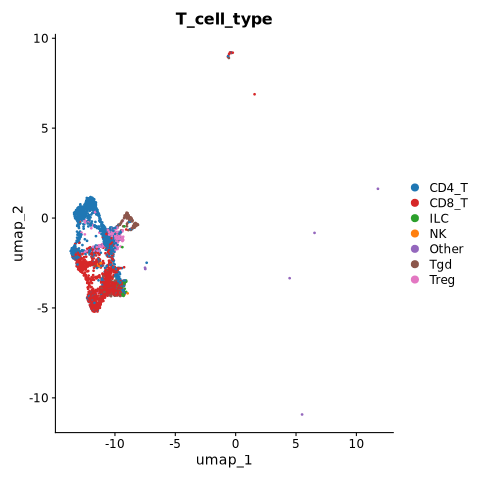

In [25]:
%%R

p1<-DimPlot(
  Tcell_integrated,
  group.by = 'T_cell_type',
  label.size = 3,
  pt.size = 0.5,
  cols = jdb_palette("corona")
)

ggsave(
  filename = "Tcells_singlecell_umap_celltype.pdf",
  plot = p1,
  width = 20,
  height = 6
)

p1

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


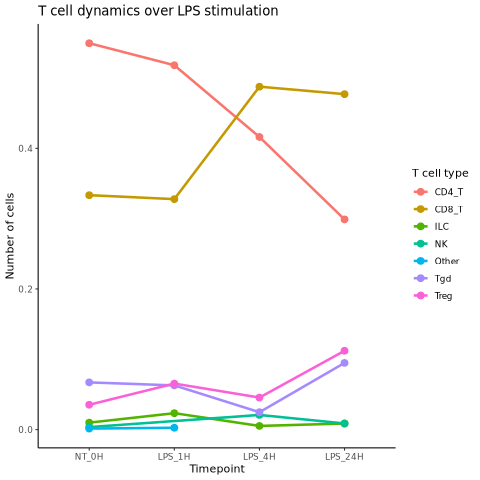

In [18]:
%%R

# Counts per timepoint
counts_new <- Tcell_integrated@meta.data %>%
  group_by(samplid_combined, T_cell_type) %>%
  tally(name = "cell_count") %>%
  group_by(samplid_combined) %>%
  mutate(fraction = cell_count / sum(cell_count))

counts_new

library(ggplot2)
library(dplyr)

# Ensure correct ordering of timepoints
df <- counts_new %>%
  mutate(samplid_combined = factor(
    samplid_combined,
    levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
  ))

# Plot
p<-ggplot(df, aes(x = samplid_combined, y = fraction, 
               color = T_cell_type, group = T_cell_type)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T cell type",
    title = "T cell dynamics over LPS stimulation"
  )

p2<-ggplot(df, aes(x = samplid_combined, y = cell_count, 
               color = T_cell_type, group = T_cell_type)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T cell type",
    title = "T cell dynamics over LPS stimulation"
  )

ggsave(
  filename = "Tcells_fraction_change_additional.pdf",
  plot = p,
  width = 6,
  height = 6
)
ggsave(
  filename = "Tcells_number_change_additional.pdf",
  plot = p2,
  width = 6,
  height = 6
)

p

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


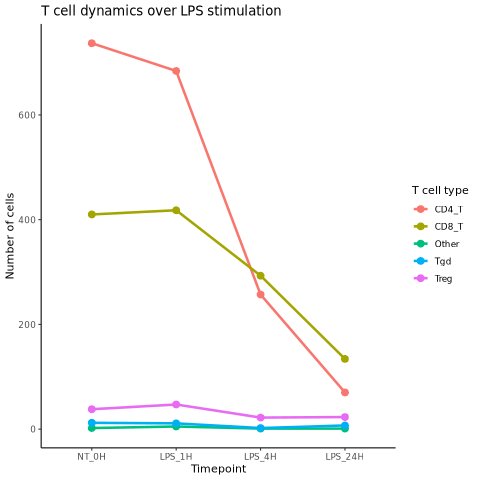

In [18]:
%%R

# Counts per timepoint
counts_new <- Tcell_integrated@meta.data %>%
  group_by(samplid_combined, T_cell_type) %>%
  tally(name = "cell_count") %>%
  group_by(samplid_combined) %>%
  mutate(fraction = cell_count / sum(cell_count))

counts_new

library(ggplot2)
library(dplyr)

# Ensure correct ordering of timepoints
df <- counts_new %>%
  mutate(samplid_combined = factor(
    samplid_combined,
    levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
  ))

# Plot
p<-ggplot(df, aes(x = samplid_combined, y = fraction, 
               color = T_cell_type, group = T_cell_type)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T cell type",
    title = "T cell dynamics over LPS stimulation"
  )

p2<-ggplot(df, aes(x = samplid_combined, y = cell_count, 
               color = T_cell_type, group = T_cell_type)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T cell type",
    title = "T cell dynamics over LPS stimulation"
  )

ggsave(
  filename = "Tcells_fraction_change.pdf",
  plot = p,
  width = 6,
  height = 6
)
ggsave(
  filename = "Tcells_number_change.pdf",
  plot = p2,
  width = 6,
  height = 6
)

p2

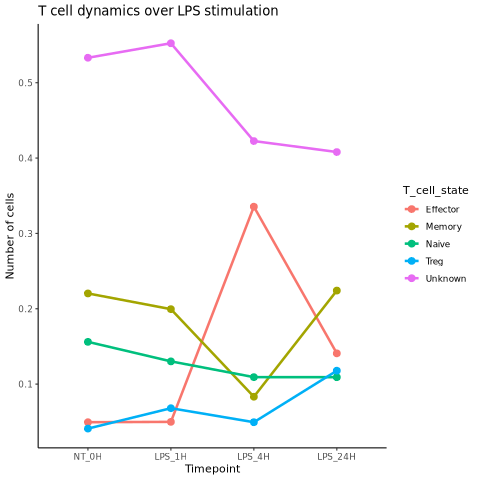

In [19]:
%%R

# Counts per timepoint
counts_new <- Tcell_integrated@meta.data %>%
  group_by(samplid_combined, T_cell_state) %>%
  tally(name = "cell_count") %>%
  group_by(samplid_combined) %>%
  mutate(fraction = cell_count / sum(cell_count))

counts_new

library(ggplot2)
library(dplyr)

# Ensure correct ordering of timepoints
df <- counts_new %>%
  mutate(samplid_combined = factor(
    samplid_combined,
    levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
  ))

# Plot
p<-ggplot(df, aes(x = samplid_combined, y = fraction, 
               color = T_cell_state, group = T_cell_state)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T_cell_state",
    title = "T cell dynamics over LPS stimulation"
  )

p2<-ggplot(df, aes(x = samplid_combined, y = cell_count, 
               color = T_cell_state, group = T_cell_state)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T_cell_state",
    title = "T cell dynamics over LPS stimulation"
  )

ggsave(
  filename = "Tcells_fraction_change_state_additional.pdf",
  plot = p,
  width = 6,
  height = 6
)
ggsave(
  filename = "Tcells_number_change_state_additional.pdf",
  plot = p2,
  width = 6,
  height = 6
)

p

In [19]:
%%R
library(dplyr)
# Make contingency table: rows = cell type, cols = timepoints
contig_new <- table(Tcell_integrated@meta.data$T_cell_type, Tcell_integrated@meta.data$samplid_combined)
chi_new <- chisq.test(contig_new)
chi_new$p.value   # overall significance



[1] 7.296802e-23


In addition: Warning message:
In chisq.test(contig_new) : Chi-squared approximation may be incorrect


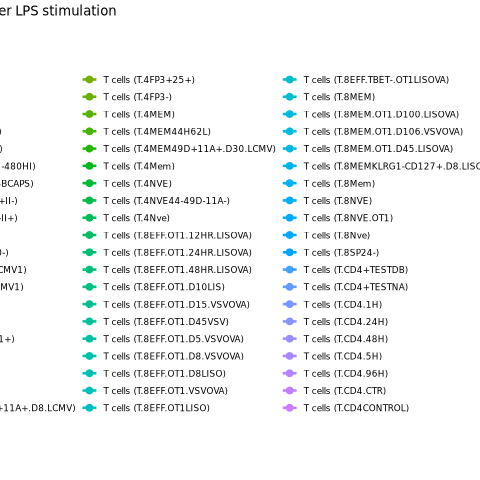

In [22]:
%%R

# Counts per timepoint
counts_new <- Tcell_integrated@meta.data %>%
  group_by(samplid_combined,SingleR.labels.fine) %>%
  tally(name = "cell_count") %>%
  group_by(samplid_combined) %>%
  mutate(fraction = cell_count / sum(cell_count))

counts_new
write.csv(counts_new,file="Tcell_fraction_change_LPS_singleRfinelabel_additional.csv")
library(ggplot2)
library(dplyr)

# Ensure correct ordering of timepoints
df <- counts_new %>%
  mutate(samplid_combined = factor(
    samplid_combined,
    levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
  ))

# Plot
p<-ggplot(df, aes(x = samplid_combined, y = fraction, 
               color = SingleR.labels.fine, group = SingleR.labels.fine)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  theme_classic() +
  labs(
    x = "Timepoint",
    y = "Number of cells",
    color = "T cell type",
    title = "T cell dynamics over LPS stimulation"
  )

ggsave(
  filename = "Tcells_fraction_change_singlerinelabel_additional.pdf",
  plot = p,
  width = 20,
  height = 6
)

p

In [35]:
%%R
write.csv
counts_new

# A tibble: 157 x 4
# Groups:   samplid_combined [4]
   samplid_combined SingleR.labels.fine               cell_count fraction
   <fct>            <chr>                                  <int>    <dbl>
 1 NT_0H            Macrophages (MF.II-480HI)                  1 0.000834
 2 NT_0H            Monocytes (MO.6C-II+)                      1 0.000834
 3 NT_0H            T cells (T.4EFF49D+11A+.D8.LCMV)           2 0.00167 
 4 NT_0H            T cells (T.4FP3+25+)                       8 0.00667 
 5 NT_0H            T cells (T.4FP3-)                          8 0.00667 
 6 NT_0H            T cells (T.4MEM)                           2 0.00167 
 7 NT_0H            T cells (T.4MEM44H62L)                    37 0.0309  
 8 NT_0H            T cells (T.4MEM49D+11A+.D30.LCMV)         81 0.0676  
 9 NT_0H            T cells (T.4Mem)                           4 0.00334 
10 NT_0H            T cells (T.4NVE)                          38 0.0317  
# i 147 more rows
# i Use `print(n = ...)` to see more rows

In [21]:
%%R

library(dplyr)
# Make contingency table: rows = cell type, cols = timepoints
contig_new <- table(Tcell_integrated@meta.data$SingleR.labels.fine, Tcell_integrated@meta.data$samplid_combined)
chi_new <- chisq.test(contig_new)
chi_new$p.value   # overall significance
contig_new

                                        
                                         NT_0H LPS_1H LPS_4H LPS_24H
  B cells (B.MEM)                            0      2      0       0
  ILC (ILC1.CD127+)                          0      1      0       0
  Macrophages (MF.II-480HI)                  1      0      0       0
  Macrophages (MF.SBCAPS)                    0      1      0       0
  Monocytes (MO.6C+II-)                      0      1      0       0
  Monocytes (MO.6C-II+)                      1      0      0       0
  NK cells (NK.DAP10-)                       0      0      0       1
  NK cells (NK.H+MCMV1)                      0      0      1       0
  NKT (NKT.4+)                               0      4      1       0
  NKT (NKT.4-)                               0      1      0       0
  T cells (T.4)                              0      1      0       0
  T cells (T.4.PLN)                          0      1      0       0
  T cells (T.4.Pa)                           0      1      0  

In addition: Warning message:
In chisq.test(contig_new) : Chi-squared approximation may be incorrect


In [ ]:
%%R

#GSEA for other singatures in T CELL which indicate activation 

%%R

#GSEA----
library(ggplot2)
library(escape)
library(GSVA)
library(RColorBrewer)
library(manhattanly)
library(msigdbr)
DefaultAssay(Tcell_integrated)  = "RNA"
Idents(Tcell_integrated) = "T_cell_type"

GS.C2 <- getGeneSets(library = "C2", species = "Mus musculus")
GS.C2.KEGG_MEDICUS<- getGeneSets(library = "C2", species = "Mus musculus", subcategory = "KEGG_MEDICUS")
GS.C2.REACTOME<- getGeneSets(library = "C2", species = "Mus musculus", subcategory = "REACTOME")
GS.C2.BIOCARTA<- getGeneSets(library = "C2", species = "Mus musculus", subcategory = "BIOCARTA")
GS.C3 <- getGeneSets(library = "C3",species = "Mus musculus")
GS.C5 <- getGeneSets(library = "C5", species = "Mus musculus")
GS.C7 <- getGeneSets(library = "C7",species = "Mus musculus")
GS.C8 <- getGeneSets(library = "C8",species = "Mus musculus")
stem_set <- GS.C8[grep("STEM-CELL", names(GS.C8))]
GS.H <- getGeneSets(library = "H",species = "Mus musculus")


CITE <- runEscape(CITE, 
                  method = "ssGSEA",
                  gene.sets = GS.H, 
                  groups = 1000, 
                  min.size = 5,
                  new.assay.name = "escape.ssGSEA.H")

CITE <- performNormalization(CITE, 
                                    assay = "escape.ssGSEA.H", 
                                    gene.sets = GS.H, 
                                    scale.factor = CITE$nFeature_RNA)

all_markers_H <- FindAllMarkers(CITE, 
                                          assay = "escape.ssGSEA.H_normalized", 
                                          min.pct = 0,
                                          logfc.threshold = 0)

write.csv(all_markers_H, file="all_markers_H.csv")

#H heatmaps
#note we used enrichment values which are not normalized by feature count per cell, it seems for hallmark to give more accurate representation
library(dplyr)
top_5_h<-all_markers_H %>% group_by(cluster) %>% slice_min(n=5, order_by = p_val_adj)
top_5_h<-unique(top_5_h$gene)

heatmapEnrichment(CITE, 
                  group.by = "ident",
                  assay = "escape.ssGSEA.H",
                  gene.set.use = top_5_h,
                  scale = TRUE,
                  cluster.rows = TRUE,
                  cluster.columns = TRUE) +  scale_fill_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) 

heatmapEnrichment(cite_subset, 
                  group.by = "ident",
                  assay = "escape.ssGSEA.H",
                  gene.set.use = rownames(CITE@assays$escape.ssGSEA.H@data)[1:50],
                  scale = TRUE,
                  cluster.rows = TRUE,
                  cluster.columns = TRUE) +  scale_fill_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) 


#Now we do for C8 as we want stem cell related signatures
CITE <- runEscape(CITE, 
                  method = "ssGSEA",
                  gene.sets = GS.C8, 
                  groups = 1000, 
                  min.size = 5,
                  new.assay.name = "escape.ssGSEA.C8")

CITE <- performNormalization(CITE, 
                                     assay = "escape.ssGSEA.C8", 
                                     gene.sets = GS.C8, 
                                     scale.factor = CITE$nFeature_RNA)

all_markers_C8 <- FindAllMarkers(CITE, 
                                assay = "escape.ssGSEA.C8_normalized", 
                                min.pct = 0,
                                logfc.threshold = 0)

write.csv(all_markers_H, file="all_markers_C8.csv")

stem_set<-grep("STEM-CELL",rownames(CITE[["escape.ssGSEA.C8"]]), value= TRUE)

heatmapEnrichment(
  CITE,
  group.by = "ident",
  gene.set.use = stem_set,
  assay = "escape.ssGSEA.C8",
  cluster.rows = TRUE,
  cluster.columns = TRUE,
  scale =TRUE,
  summary.stat = "mean",
)+ scale_fill_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) 


saveRDS(CITE, file="CITE_classic_with_gsea_correlation.RDS")

#==============================================================
#==============================================================

#Making custom GSEA plots after differential enrichment
library(fgsea)
library(dplyr)
library(Seurat)
library(clusterProfiler)
library(BuenColors)

# Pull out just the columns corresponding to gene symbols and LogFC
Cluster_marker <- dplyr::select(RNA_marker_leiden_05_classic,X,avg_log2FC,cluster) #KD means knockdown, 01 means FDR 1%, I selected gene name and stat value
CLuster_marker<-as.data.frame(Cluster_marker)

#Cluster7 specific gsea plots
Cluster_marker_7 <- Cluster_marker %>% dplyr::filter(Cluster_marker$cluster == 7) %>% dplyr::select(X,avg_log2FC)
Cluster_marker_7<-na.omit(Cluster_marker_7)
# construct a named vector
Cluster_marker_7_rnk <- Cluster_marker_7$avg_log2FC
names(Cluster_marker_7_rnk) <- as.character(Cluster_marker_7$X)
Cluster_marker_7_rnk <- sort(Cluster_marker_7_rnk, decreasing = TRUE)

#USING ENRICH IT
GSEA.results.stemcells.C7.enrichIT <- enrichIt(input.data = Cluster_marker_7_rnk, 
                                   gene.sets = GS.C8

)               

GSEA.results.H.C7.enrchIT <- enrichIt(input.data = Cluster_marker_7_rnk, 
                                   gene.sets = GS.H
)            

?enrichItPlot
enrichItPlot(GSEA.results.H.C7.enrchIT,"cnet") + 
  theme(strip.background = element_blank(),
        strip.text.x = element_blank())


#using GSEA in cluster profiler
# are also retrieved as tibbles
msigdbr_species()
ms_gsea <- msigdbr(species = "Mus musculus") #gets all collections/signatures with human gene IDs
#take a look at the categories and subcategories of signatures available to you
ms_gsea %>% 
  dplyr::distinct(gs_cat, gs_subcat) %>% 
  dplyr::arrange(gs_cat, gs_subcat)
# choose a specific msigdb collection/subcollection
# since msigdbr returns a tibble, we'll use dplyr to do a bit of wrangling
ms_gsea_H <- msigdbr(species = "Mus musculus", # change depending on species your data came from
                      category = "H") %>% # choose your msigdb collection of interest
  dplyr::select(gs_name, gene_symbol) #just get the columns corresponding to signature name and gene symbols of genes in each signature 

ms_gsea_C8 <- msigdbr(species = "Mus musculus", # change depending on species your data came from
                     category = "C8") %>% # choose your msigdb collection of interest
  dplyr::select(gs_name, gene_symbol) #just get the columns corresponding to signature name and gene symbols of genes in each signature 



GSEA.results.H.C7.clusterprofiler<- GSEA(Cluster_marker_7_rnk, TERM2GENE=ms_gsea_H, verbose=FALSE, eps=0, pvalueCutoff = 1,by="fgsea",minGSSize = 5)
GSEA.results.H.C7.clusterprofiler_t<-as.tibble(GSEA.results.H.C7.clusterprofiler)

GSEA.results.C8.CLUSTER7.clusterprofiler<- GSEA(Cluster_marker_7_rnk, TERM2GENE=ms_gsea_C8, verbose=FALSE, eps=0, pvalueCutoff = 1,by="fgsea",minGSSize = 5)
GSEA.results.C8.CLUSTER7.clusterprofiler_t<-as.tibble(GSEA.results.C8.CLUSTER7.clusterprofiler)

gseaplot2(GSEA.results.C8.CLUSTER7.clusterprofiler, 
          geneSetID = c(1:5), #can choose multiple signatures to overlay in this plot
          pvalue_table = FALSE, #can set this to FALSE for a cleaner plot
          color= c("#ECCBAE", "#046C9A", "#D69C4E", "#ABDDDE", "#000000"))#can also turn off this title

write.csv(GSEA.results.C8.CLUSTER7.clusterprofiler_t, file="GSEA.results.C8.CLUSTER7.clusterprofiler_t_citeinvitro.csv")


#Cluster 1

Cluster_marker_1 <- Cluster_marker %>% dplyr::filter(Cluster_marker$cluster == 1) %>% dplyr::select(X,avg_log2FC)
Cluster_marker_1<-na.omit(Cluster_marker_1)
# construct a named vector
Cluster_marker_1_rnk <- Cluster_marker_1$avg_log2FC
names(Cluster_marker_1_rnk) <- as.character(Cluster_marker_1$X)
Cluster_marker_1_rnk <- sort(Cluster_marker_1_rnk, decreasing = TRUE)

GSEA.results.H.C1 <- enrichIt(input.data = Cluster_marker_1_rnk, 
                           gene.sets = GS.H,
                           
)      

GSEA.results.H.C1<- GSEA(Cluster_marker_1_rnk, TERM2GENE=ms_gsea_H, verbose=FALSE)






library(GSEABase)
library(enrichplot)
gseaplot2(GSEA.results.H.C7, 
          geneSetID = c(1:5), #can choose multiple signatures to overlay in this plot
          pvalue_table = FALSE, #can set this to FALSE for a cleaner plot
          base_size = 16) #can also turn off this title









In [22]:
%%R

Unintegrated_sc@reductions

$pca
A dimensional reduction object with key PC_ 
 Number of dimensions: 50 
 Number of cells: 43653 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: RNA 

$tsne
A dimensional reduction object with key tSNE_ 
 Number of dimensions: 2 
 Number of cells: 43653 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: RNA 

$umap
A dimensional reduction object with key umap_ 
 Number of dimensions: 2 
 Number of cells: 43653 
 Projected dimensional reduction calculated:  FALSE 
 Jackstraw run: FALSE 
 Computed using assay: RNA 



In [32]:
%%R
head(Macrophages_unitegrated@meta.data)

                           orig.ident nCount_RNA nFeature_RNA sampleid
AAACAAGCAGGGCTATATTCGGTT-1          1      13826         3105  LPS_24H
AAACCAGGTCTGTGATATTCGGTT-1          1      12746         3103  LPS_24H
AAACGTTCACCATCCAATTCGGTT-1          1      14291         3552  LPS_24H
AAAGCATGTTGGATGAATTCGGTT-1          1       8222         3319  LPS_24H
AAAGGCTTCGCAAATAATTCGGTT-1          1      10450         3085  LPS_24H
AAAGGGATCAATACAGATTCGGTT-1          1       9831         3355  LPS_24H
                           percent.mt RNA_snn_res.0.5 seurat_clusters
AAACAAGCAGGGCTATATTCGGTT-1 0.07956025              11              11
AAACCAGGTCTGTGATATTCGGTT-1 0.16475757              11              11
AAACGTTCACCATCCAATTCGGTT-1 0.10496116              11              11
AAAGCATGTTGGATGAATTCGGTT-1 0.27973729              19              19
AAAGGCTTCGCAAATAATTCGGTT-1 0.07655502              11              11
AAAGGGATCAATACAGATTCGGTT-1 0.44756383              11              11
             

In [ ]:
%%R



In [12]:
%%R

#Here we process everything by ourself
set.seed(42)
Matrix_D24<- Macrophages_unitegrated[["RNA"]]$counts
Pheno_D24<- Macrophages_unitegrated@meta.data
Feature_D24<- data.frame(gene_short_name=rownames(Macrophages_unitegrated), row.names= rownames(Macrophages_unitegrated))


Macrophages_unitegrated_cds <- new_cell_data_set(Matrix_D24, 
                              cell_metadata = Pheno_D24,
                              gene_metadata = Feature_D24)

Macrophages_unitegrated_cds <- preprocess_cds(Macrophages_unitegrated_cds, num_dim = 100)


## Step 3: Reduce the dimensions using UMAP
Macrophages_unitegrated_cds <- reduce_dimension(Macrophages_unitegrated_cds)

## Step 4: Cluster the cells
Macrophages_unitegrated_cds <- cluster_cells(Macrophages_unitegrated_cds)

## Step 5: Learn a graph
Macrophages_unitegrated_cds <- learn_graph(Macrophages_unitegrated_cds)





  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


No preprocess_method specified, using preprocess_method = 'PCA'
Registered S3 methods overwritten by 'proxy':
  method               from    
  print.registry_field registry
  print.registry_entry registry


R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: ggrepel: 8 unlabeled data points (too many overlaps). Consider increasing max.overlaps 



Info: save_monocle_objects: saving monocle object files:
  cds_object.rds  (full_cds:  RDS from cell_data_set)
  rdd_umap_transform_model_umap.idx  (UMAP:  UMAP_NN_index from reduce_dimension)
Info: checking for monocle object files...
  Macrophage_monocle_singlecell/cds_object.rds...OK
  Macrophage_monocle_singlecell/rdd_umap_transform_model_umap.idx...OK
Info: all expected monocle object files exist.
Info: making a tar file of the output directory...
  made tar archive file "Macrophage_monocle_singlecell.tar"
  Done.
In addition: Warning messages:
1: ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps 
2: invalid uid value replaced by that for user 'nobody' 


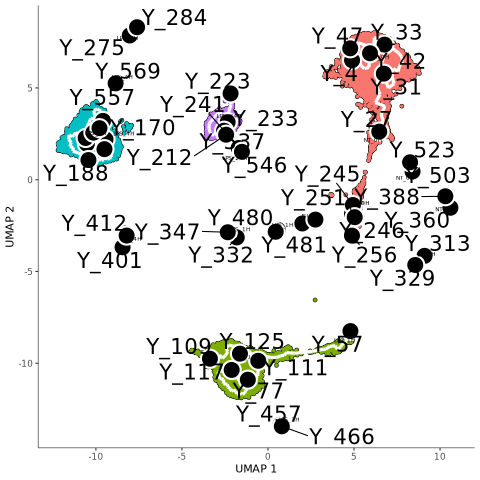

In [34]:
%%R
p5<-plot_cells(
  Macrophages_unitegrated_cds,
  color_cells_by = "sampleid",
  label_leaves = FALSE,
  label_branch_points = TRUE,
  graph_label_size = 5,
  cell_size=1,
  alpha=1,
  trajectory_graph_segment_size = 1.5,
  trajectory_graph_color = "white",
  label_principal_points = TRUE
) 

ggsave(
  filename = "Macrophage_umap_monocle.pdf",
  plot = p5,
  width = 7,
  height = 6
)

save_monocle_objects(Macrophages_unitegrated_cds, "Macrophage_monocle_singlecell")

p5



In [38]:
%%R
head(Tcell_integrated@meta.data)

                           orig.ident nCount_RNA nFeature_RNA  sampleid
AACATTGAGCTCGATCATTCGGTT-1          1       2426         1556 LPS_24H_3
AACCAGGTCGATATAGATTCGGTT-1          1       1319         1006 LPS_24H_3
AACCAGGTCGTTAGGGATTCGGTT-1          1       1409         1078 LPS_24H_3
AAGCCTTGTAATGAACATTCGGTT-1          1       1687         1257 LPS_24H_3
AAGGTATGTCCTCCTGATTCGGTT-1          1       3581         2299 LPS_24H_3
AAGTACCAGCTTATCGATTCGGTT-1          1       1322         1020 LPS_24H_3
                           percent.mt RNA_snn_res.0.5 seurat_clusters
AACATTGAGCTCGATCATTCGGTT-1  0.3709810               8              12
AACCAGGTCGATATAGATTCGGTT-1  0.3032600              11               7
AACCAGGTCGTTAGGGATTCGGTT-1  0.9936125              11               7
AAGCCTTGTAATGAACATTCGGTT-1  0.7113219               8              12
AAGGTATGTCCTCCTGATTCGGTT-1  0.7260542               8              12
AAGTACCAGCTTATCGATTCGGTT-1  0.5295008              11               7
      

  |======================================================================| 100%


No preprocess_method specified, using preprocess_method = 'PCA'
Info: save_monocle_objects: saving monocle object files:
  cds_object.rds  (full_cds:  RDS from cell_data_set)
  rdd_umap_transform_model_umap.idx  (UMAP:  UMAP_NN_index from reduce_dimension)
Info: checking for monocle object files...
  /group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell/Tcell_monocle_singlecell/cds_object.rds...OK
  /group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell/Tcell_monocle_singlecell/rdd_umap_transform_model_umap.idx...OK
Info: all expected monocle object files exist.
Info: making a tar file of the output directory...
  made tar archive file "/group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell/Tcell_monocle_singlecell.tar"
  Done.
In addition: Warning messages:
1: In tar(tarfile = archive_name, files = directory_path, compression = archive_control[["archive_compression"]]) :
  storing paths of more than 100 bytes is not portable:
  '/group/crtd_sieweke/DATA/Soni/HomoHet_JLA/Single_cell/Tcel

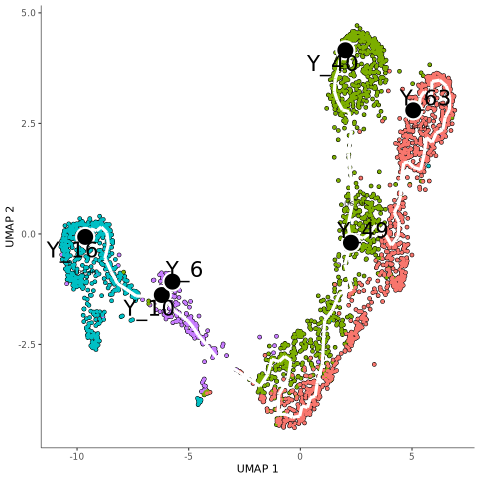

In [13]:
%%R

#Tcell

#Here we process everything by ourself
set.seed(42)
Matrix_D24<- Tcell_integrated[["RNA"]]$counts
Pheno_D24<- Tcell_integrated@meta.data
Feature_D24<- data.frame(gene_short_name=rownames(Tcell_integrated), row.names= rownames(Tcell_integrated))


Tcell_integrated_cds <- new_cell_data_set(Matrix_D24, 
                              cell_metadata = Pheno_D24,
                              gene_metadata = Feature_D24)

Tcell_integrated_cds <- preprocess_cds(Tcell_integrated_cds, num_dim = 100)


## Step 3: Reduce the dimensions using UMAP
Tcell_integrated_cds <- reduce_dimension(Tcell_integrated_cds)

## Step 4: Cluster the cells
Tcell_integrated_cds <- cluster_cells(Tcell_integrated_cds)

## Step 5: Learn a graph
Tcell_integrated_cds <- learn_graph(Tcell_integrated_cds)

p5<-plot_cells(
  Tcell_integrated_cds,
  color_cells_by = "samplid_combined",
  label_leaves = FALSE,
  label_branch_points = TRUE,
  graph_label_size = 5,
  cell_size=1,
  alpha=1,
  trajectory_graph_segment_size = 1.5,
  trajectory_graph_color = "white",
  label_principal_points = TRUE
) 

ggsave(
  filename = "Tcell_umap_monocle.pdf",
  plot = p5,
  width = 7,
  height = 6
)

save_monocle_objects(Tcell_integrated_cds, "Tcell_monocle_singlecell")

p5



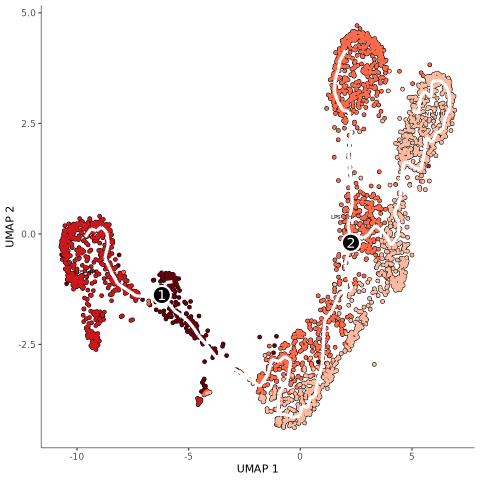

In [43]:
%%R

timepoint_cols <- c(
  "NT_0H" = "#FCBBA1",
  "LPS_1H" = "#FB6A4A",
  "LPS_4H" = "#CB181D",
  "LPS_24H" = "#67000D"
)
Tcell_integrated_cds@colData$samplid_combined <- factor(
  Tcell_integrated_cds@colData$samplid_combined,
  levels = c("NT_0H", "LPS_1H", "LPS_4H", "LPS_24H")
)
p5<-plot_cells(
  Tcell_integrated_cds,
  color_cells_by = "samplid_combined",
  label_leaves = FALSE,
  graph_label_size = 5,
  cell_size=1,
  alpha=1,
  label_cell_group=TRUE,
  trajectory_graph_segment_size = 1.5,
  trajectory_graph_color = "white") + scale_color_manual(values = timepoint_cols)
ggsave(
  filename = "Tcell_umap_monocle_timepoints.pdf",
  plot = p5,
  width = 7,
  height = 6
)
p5

In [44]:
%%R
p5<-plot_cells(
  Tcell_integrated_cds,
  color_cells_by = "pseudotime",
  label_leaves = FALSE,
  graph_label_size = 5,
  cell_size=1,
  alpha=1,
  label_cell_group=TRUE,
  trajectory_graph_segment_size = 1.5,
  trajectory_graph_color = "white") + scale_color_manual(values = timepoint_cols)
ggsave(
  filename = "Tcell_umap_monocle_pseudotime.pdf",
  plot = p5,
  width = 7,
  height = 6
)
p5

Error in value[[3L]](cond) : 
  No pseudotime for UMAP calculated. Please run order_cells with reduction_method = UMAP before attempting to color by pseudotime.


RInterpreterError: Failed to parse and evaluate line 'p5<-plot_cells(\n  Tcell_integrated_cds,\n  color_cells_by = "pseudotime",\n  label_leaves = FALSE,\n  graph_label_size = 5,\n  cell_size=1,\n  alpha=1,\n  label_cell_group=TRUE,\n  trajectory_graph_segment_size = 1.5,\n  trajectory_graph_color = "white") + scale_color_manual(values = timepoint_cols)\nggsave(\n  filename = "Tcell_umap_monocle_pseudotime.pdf",\n  plot = p5,\n  width = 7,\n  height = 6\n)\np5\n'.
R error message: 'Error in value[[3L]](cond) : \n  No pseudotime for UMAP calculated. Please run order_cells with reduction_method = UMAP before attempting to color by pseudotime.'

In [48]:
%%R

# Get root cells based on metadata
root_cells <- colnames(Tcell_integrated_cds)[
  colData(Tcell_integrated_cds)$samplid_combined == "NT_0H"
]
root_cell <- root_cells[1]
# Order cells using ALL these as roots
Tcell_integrated_cds <- order_cells(Tcell_integrated_cds, root_cells = root_cell)

Cells aren't colored in a way that allows them to be grouped.


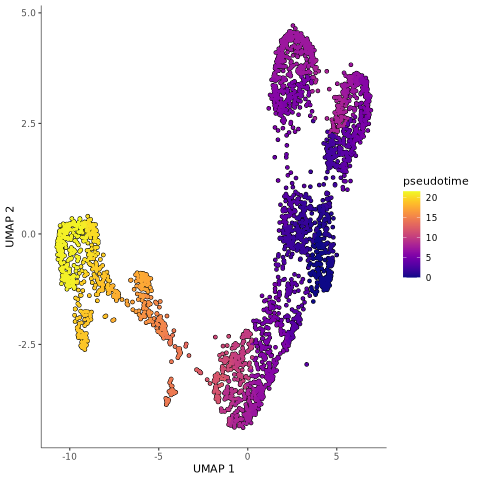

In [49]:
%%R

#when root cells are cluster 10
p2<-plot_cells(Tcell_integrated_cds,
           color_cells_by = "pseudotime",
           label_cell_groups=TRUE,
           label_leaves=TRUE,
           label_branch_points=TRUE,
           graph_label_size=0,
           cell_size=1,
           alpha=1,
           trajectory_graph_segment_size = 0,
           trajectory_graph_color = "white",
           )
ggsave(
  filename = "Tcell_integrated_cds_pseudotime.pdf",
  plot = p2,
  width = 7,
  height = 6
)

p2

In [8]:
%%R
Tcell_integrated_cds <- load_monocle_objects(directory_path = 'Tcell_monocle_singlecell')


In [ ]:
%%R
highlight_genes_tcell<-c("Cd)
Macrophages_unitegrated_cds_highlight_genes 

In [50]:
%%R

#https://cole-trapnell-lab.github.io/monocle3/docs/differential/#regression-analysis

highlight_genes<-c("C1qa","C1qb","C1qc","Fos","Fosl2","Mafb","Vsig4","Timd4")
Macrophages_unitegrated_cds_highlight_genes <- Macrophages_unitegrated_cds[rowData(Macrophages_unitegrated_cds)$gene_short_name %in% highlight_genes,]
gene_fits <- fit_models(Macrophages_unitegrated_cds_highlight_genes, model_formula_str = "~")
fit_coefs <- coefficient_table(gene_fits)
fit_coefs


highlight_genes_activationmark<-c("C1qa","C1qb","C1qc","Fos","Fosl2","Mafb","Vsig4","Timd4")
Macrophages_unitegrated_cds_highlight_genes <- Macrophages_unitegrated_cds[rowData(Macrophages_unitegrated_cds)$gene_short_name %in% highlight_genes,]
gene_fits <- fit_models(Macrophages_unitegrated_cds_highlight_genes, model_formula_str = "~")
fit_coefs <- coefficient_table(gene_fits)
fit_coefs

# A tibble: 32 x 14
   gene_short_name num_cells_expressed gene_id model        model_summary status
   <chr>                         <int> <chr>   <named list> <named list>  <chr> 
 1 Mafb                          10887 Mafb    <speedglm>   <smmry.sp>    OK    
 2 Mafb                          10887 Mafb    <speedglm>   <smmry.sp>    OK    
 3 Mafb                          10887 Mafb    <speedglm>   <smmry.sp>    OK    
 4 Mafb                          10887 Mafb    <speedglm>   <smmry.sp>    OK    
 5 C1qb                          13670 C1qb    <speedglm>   <smmry.sp>    OK    
 6 C1qb                          13670 C1qb    <speedglm>   <smmry.sp>    OK    
 7 C1qb                          13670 C1qb    <speedglm>   <smmry.sp>    OK    
 8 C1qb                          13670 C1qb    <speedglm>   <smmry.sp>    OK    
 9 C1qc                          12902 C1qc    <speedglm>   <smmry.sp>    OK    
10 C1qc                          12902 C1qc    <speedglm>   <smmry.sp>    OK    
# i 22 m

In [51]:
%%R

emb_time_terms %>% filter (q_value < 0.05) %>%
         select(gene_short_name, term, q_value, estimate)

Error in select(., gene_short_name, term, q_value, estimate) : 
  unused arguments (gene_short_name, term, q_value, estimate)


RInterpreterError: Failed to parse and evaluate line '\nemb_time_terms %>% filter (q_value < 0.05) %>%\n         select(gene_short_name, term, q_value, estimate)\n'.
R error message: 'Error in select(., gene_short_name, term, q_value, estimate) : \n  unused arguments (gene_short_name, term, q_value, estimate)'

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In scale_y_log10() :
R[write to console]:  log-10 transformation introduced infinite values.

R[write to console]: 2: 
R[write to console]: In scale_y_log10() :
R[write to console]:  log-10 transformation introduced infinite values.

R[write to console]: 3: 
R[write to console]: In scale_y_log10() :
R[write to console]:  log-10 transformation introduced infinite values.

R[write to console]: 4: Removed 28802 rows containing non-finite outside the scale range
(`stat_ydensity()`). 

R[write to console]: 5: Removed 28802 rows containing non-finite outside the scale range
(`stat_summary()`). 



In addition: Warning messages:
1: In scale_y_log10() : log-10 transformation introduced infinite values.
2: In scale_y_log10() : log-10 transformation introduced infinite values.
3: In scale_y_log10() : log-10 transformation introduced infinite values.
4: Removed 28802 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
5: Removed 28802 rows containing non-finite outside the scale range
(`stat_summary()`). 


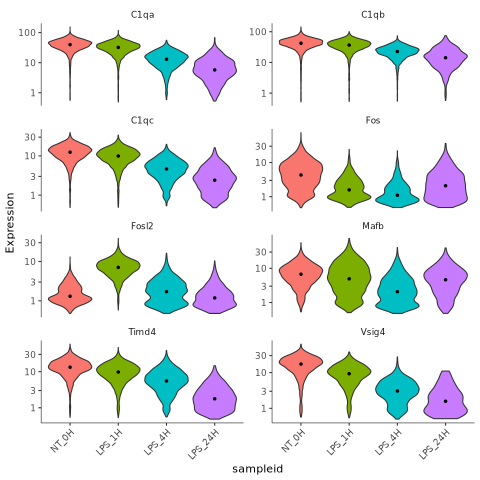

In [59]:
%%R

p<-plot_genes_violin(Macrophages_unitegrated_cds_highlight_genes, group_cells_by="sampleid", ncol=2) +
      theme(axis.text.x=element_text(angle=45, hjust=1))
p+scale_color_manual(values = timepoint_cols)

ggsave(
  filename = "Macrophage_integrated_violinplot_selected_gene.pdf",
  plot = p,
  width = 8,
  height = 8
)
p

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: In scale_y_log10() :
R[write to console]:  log-10 transformation introduced infinite values.



In addition: Warning message:
In scale_y_log10() : log-10 transformation introduced infinite values.


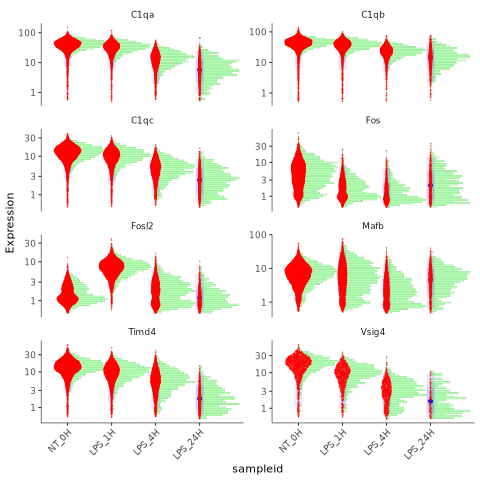

In [60]:
%%R

p<-plot_genes_hybrid(Macrophages_unitegrated_cds_highlight_genes, group_cells_by="sampleid", ncol=2) +
      theme(axis.text.x=element_text(angle=45, hjust=1))
ggsave(
  filename = "Macrophage_integrated_violinplot_selected_gene_2.pdf",
  plot = p,
  width = 8,
  height = 8
)
p
#Similar can be done for different geneset
#Further more models can be evaluated to see if they really explain the geneset expression in question

  |======================================================================| 100%


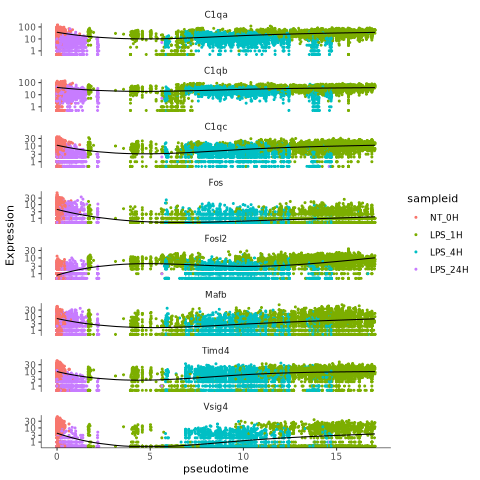

In [63]:
%%R


library(monocle3)

Macrophages_unitegrated_cds_highlight_genes <- cluster_cells(
  Macrophages_unitegrated_cds_highlight_genes,
  reduction_method = "UMAP"
)

# Learn trajectory graph with ONE partition
Macrophages_unitegrated_cds_highlight_genes <- learn_graph(
  Macrophages_unitegrated_cds_highlight_genes,
  use_partition = FALSE
)

# Define root cells (NT_0H)
root_cells <- colnames(Macrophages_unitegrated_cds_highlight_genes)[
  colData(Macrophages_unitegrated_cds_highlight_genes)$sampleid == "NT_0H"
]

# Order cells in pseudotime using ALL root cells
Macrophages_unitegrated_cds_highlight_genes <- order_cells(
  Macrophages_unitegrated_cds_highlight_genes,
  root_cells = root_cells
)

# Plot trajectory colored by pseudotime
p_traj <- plot_cells(
  Macrophages_unitegrated_cds_highlight_genes,
  color_cells_by = "pseudotime",
  label_cell_groups = FALSE,
  label_leaves = FALSE,
  label_branch_points = FALSE,
  graph_label_size = 4
)

# Save trajectory plot
ggsave("Macrophage_pseudotime_trajectory.pdf", p_traj, width = 7, height = 6)

# Plot genes in pseudotime
p_genes <- plot_genes_in_pseudotime(
  Macrophages_unitegrated_cds_highlight_genes,
  color_cells_by = "sampleid",
  min_expr = 0.5
)

# Save gene plot
ggsave("Macrophage_genes_pseudotime.pdf", p_genes, width = 7, height = 6)
p_genes

In [102]:
%%R

#Now we will also see graph_test, which moran's I, this is for the purpose of finding driver genes for T cell and macrophage 

pr_graph_test_res <- graph_test(cds_D24, neighbor_graph="knn")
pr_deg_ids <- row.names(subset(pr_graph_test_res, q_value < 0.05))
head(pr_deg_ids)

  |=======================================================| 100%, Elapsed 42:53
[1] "Rp1"     "Mrpl15"  "Lypla1"  "Tcea1"   "Rgs20"   "Atp6v1h"


In [104]:
%%R
gene_module_df <- find_gene_modules(cds_D24[pr_deg_ids,], resolution=1e-2)
write.csv(gene_module_df

In [113]:
%%R

#write.csv(gene_module_df, file="gene_module_df_cds_D24.csv")
head(gene_module_df)

# A tibble: 6 x 5
  id      module supermodule dim_1  dim_2
  <chr>   <fct>  <fct>       <dbl>  <dbl>
1 Rp1     30     1            4.04  4.60 
2 Mrpl15  38     1            2.60  2.16 
3 Lypla1  32     1            1.35  1.33 
4 Tcea1   45     1            1.96  2.61 
5 Rgs20   40     1           -3.08 -5.44 
6 Atp6v1h 18     1           -1.58  0.551


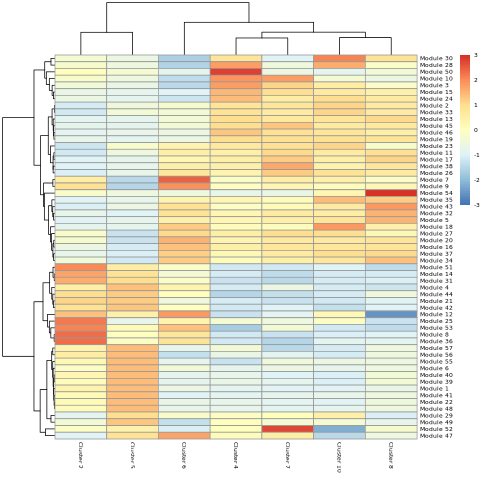

In [111]:
%%R
# Create a tibble mapping each cell to its group 
cell_group_df <- tibble::tibble(
  cell = row.names(colData(cds_D24)),
  cell_group = colData(cds_D24)$Leidencellcycle_3
)

# Aggregate gene expression by your custom groups
agg_mat <- aggregate_gene_expression(cds_D24, gene_module_df, cell_group_df)

# Set readable row and column names
row.names(agg_mat) <- stringr::str_c("Module ", row.names(agg_mat))
colnames(agg_mat) <- stringr::str_c("Cluster ", colnames(agg_mat))

# Plot heatmap
pheatmap::pheatmap(
  agg_mat,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  scale = "column",
  clustering_method = "ward.D2",
  fontsize = 6
)

#they need to be manually curated with literature search, this is similar to nmf or finisding cluster markers


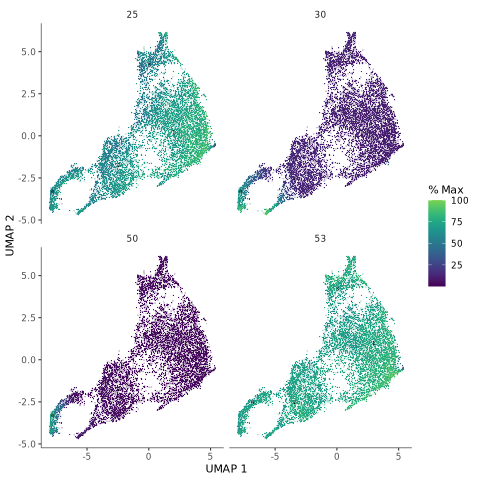

In [115]:
%%R

plot_cells(cds_D24, 
           genes=gene_module_df %>% filter(module %in% c(50, 30, 25, 53)),
           #group_cells_by= colData(cds_D24)$Leidencellcycle_3,
           #color_cells_by= colData(cds_D24)$Leidencellcycle_3,
           show_trajectory_graph=FALSE)

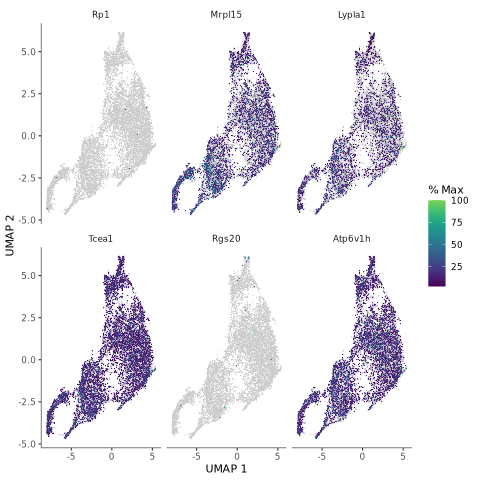

In [117]:
%%R
#Just an example of some genes in modules which might be important 
plot_cells(cds_D24, genes=c("Rp1","Mrpl15","Lypla1","Tcea1","Rgs20","Atp6v1h"),
           show_trajectory_graph=FALSE,
           label_cell_groups=FALSE,
           label_leaves=FALSE)

In [121]:
%%R

#pr_graph_test_res_umap <- graph_test(cds_D24, neighbor_graph="principal_graph")
pr_deg_ids_umap <- row.names(subset(pr_graph_test_res_umap, q_value < 0.005))
gene_module_df_umap <- find_gene_modules(cds_D24[pr_deg_ids_umap,], resolution=c(10^seq(-6,-1)))
write.csv(gene_module_df_umap, file="gene_module_df_umap_D24_monocle.csv")

In [37]:
%%R

library(CellChat)
library(patchwork)

#cite_D24<-readRDS("cite_D24_withoutdoublet_soupX_processed_leidencellcycle_newumap.RDS")

data.input.D24<-unitegrated[["RNA"]]$data
labels_D24 <- Idents(cite_D24)
meta_D24 <- data.frame(labels = labels_D24, row.names = names(labels_D24)) # create a dataframe of the cell labels
cellChat_D24 <- createCellChat(object = data.input.D24, meta = meta_D24, group.by = "labels")
print(cellChat_D24)


[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  2, 4, 5, 6, 7, 8, 10 
An object of class CellChat created from a single dataset 
 24462 genes.
 8499 cells. 
CellChat analysis of single cell RNA-seq data! 


In addition: Warning message:
In createCellChat(object = data.input.D24, meta = meta_D24, group.by = "labels") :
  The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 



In [127]:
%%R

save_monocle_objects(cds_D24, "cds_D24_monocle")
#save_monocle_objects(cds_D24_pca,"cds_D24_pca_monocle")
#save_monocle_objects(cds_D9, "cds_D9_moncole")
#save_monocle_objects(cds_D9_pca, "cds_D9_monocle_pca")
        

Info: save_monocle_objects: saving monocle object files:
  cds_object.rds  (full_cds:  RDS from cell_data_set)
  rdd_umap_transform_model_umap.idx  (UMAP:  UMAP_NN_index from reduce_dimension)
Info: checking for monocle object files...
  /group/sieweke_alveolarstem/Data/CITE_Seq/LAB5588/RNA/Analysis_R/SoupX_DBL_DSB/CellCycle_Analysis/cds_D24_monocle/cds_object.rds...OK
  /group/sieweke_alveolarstem/Data/CITE_Seq/LAB5588/RNA/Analysis_R/SoupX_DBL_DSB/CellCycle_Analysis/cds_D24_monocle/rdd_umap_transform_model_umap.idx...OK
Info: all expected monocle object files exist.
Info: making a tar file of the output directory...
  made tar archive file "/group/sieweke_alveolarstem/Data/CITE_Seq/LAB5588/RNA/Analysis_R/SoupX_DBL_DSB/CellCycle_Analysis/cds_D24_monocle.tar"
  Done.
Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'metadata': object 'cds_D9' not found
In addition: Warning messages:
1: In tar(tarfile = archive_name, files = 

RInterpreterError: Failed to parse and evaluate line '\nsave_monocle_objects(cds_D24, "cds_D24_monocle")\n#save_monocle_objects(cds_D24_pca,"cds_D24_pca_monocle")\nsave_monocle_objects(cds_D9, "cds_D9_moncole")\n#save_monocle_objects(cds_D9_pca, "cds_D9_monocle_pca")\n        \n'.
R error message: "Error in h(simpleError(msg, call)) : \n  error in evaluating the argument 'x' in selecting a method for function 'metadata': object 'cds_D9' not found"
R stdout:
Info: save_monocle_objects: saving monocle object files:
  cds_object.rds  (full_cds:  RDS from cell_data_set)
  rdd_umap_transform_model_umap.idx  (UMAP:  UMAP_NN_index from reduce_dimension)
Info: checking for monocle object files...
  /group/sieweke_alveolarstem/Data/CITE_Seq/LAB5588/RNA/Analysis_R/SoupX_DBL_DSB/CellCycle_Analysis/cds_D24_monocle/cds_object.rds...OK
  /group/sieweke_alveolarstem/Data/CITE_Seq/LAB5588/RNA/Analysis_R/SoupX_DBL_DSB/CellCycle_Analysis/cds_D24_monocle/rdd_umap_transform_model_umap.idx...OK
Info: all e

In [12]:
%%R
cds_D24 <- load_monocle_objects('cds_D24_monocle/')

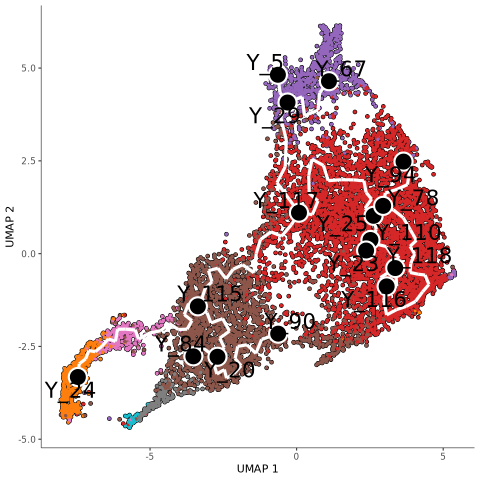

In [17]:
%%R

cols = c("#d62728","#ff7f0e","#9467bd","#8c564b","#e377c2","#7f7f7f",
                 "#17becf")

plot_cells(
  cds_D24,
  color_cells_by = "Leidencellcycle_3",
  label_groups_by_cluster = TRUE,
  label_leaves = FALSE,
  label_branch_points = TRUE,
  graph_label_size = 5,
  cell_size=1,
  alpha=1,
  trajectory_graph_segment_size = 1.5,
  trajectory_graph_color = "white",
  label_principal_points = TRUE
) +
  scale_color_manual(values = cols)

Cells aren't colored in a way that allows them to be grouped.


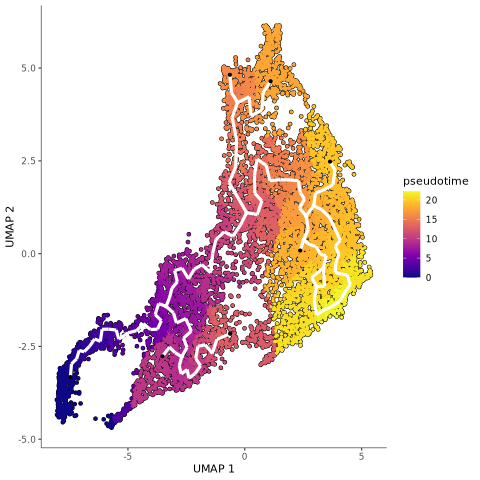

In [19]:
%%R

cds_D24 <- order_cells(cds_D24, root_pr_nodes = "Y_24")

#when root cells are cells in homeostatic population
plot_cells(cds_D24,
           color_cells_by = "pseudotime",
           label_cell_groups=TRUE,
           label_leaves=TRUE,
           label_branch_points=TRUE,
           graph_label_size=0,
           cell_size=1,
           alpha=1,
           trajectory_graph_segment_size = 1.5,
           trajectory_graph_color = "white",
           )


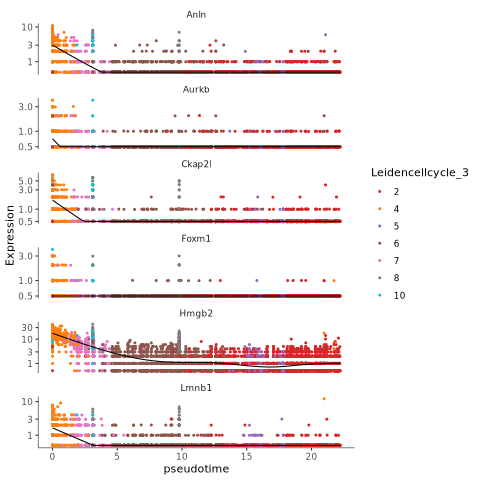

In [28]:
%%R

Holoclone <- c("Lmnb1","Ccna","Ckap2l","Anln","Aurkb","Hmgb2","Foxm1")
cds_subset_D24_holoclone <- cds_D24[rowData(cds_D24)$gene_short_name %in% Holoclone,]

cds_subset_D24_holoclone <- order_cells(cds_subset_D24_holoclone, root_pr_nodes = "Y_24")


cols = c("#d62728","#ff7f0e","#9467bd","#8c564b","#e377c2","#7f7f7f",
                 "#17becf")
plot_genes_in_pseudotime(cds_subset_D24_holoclone,
                         color_cells_by="Leidencellcycle_3",
                         trend_formula = "~ splines::ns(pseudotime, df=5)",
                         min_expr=0.5) +
  scale_color_manual(values = cols)


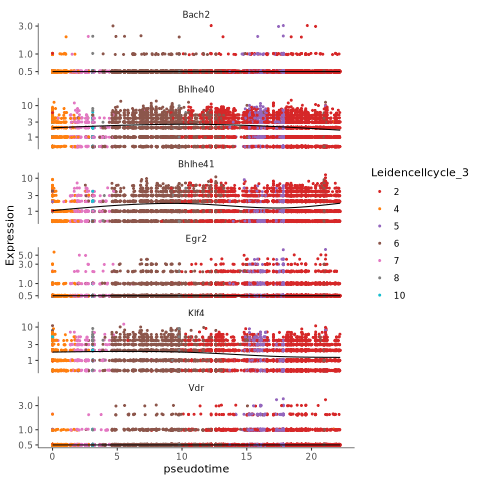

In [29]:
%%R
SR<-c("Egr2","Bhlhe40","Bhlhe41","Bach2","Klf4","Vdr")
cds_subset_D24_selfrenewalgenes <- cds_D24[rowData(cds_D24)$gene_short_name %in% SR,]

cds_subset_D24_selfrenewalgenes <- order_cells(cds_subset_D24_selfrenewalgenes, root_pr_nodes = "Y_24")


cols = c("#d62728","#ff7f0e","#9467bd","#8c564b","#e377c2","#7f7f7f",
                 "#17becf")
plot_genes_in_pseudotime(cds_subset_D24_selfrenewalgenes,
                         color_cells_by="Leidencellcycle_3",
                         trend_formula = "~ splines::ns(pseudotime, df=3)",
                         min_expr=0.5) +
  scale_color_manual(values = cols)


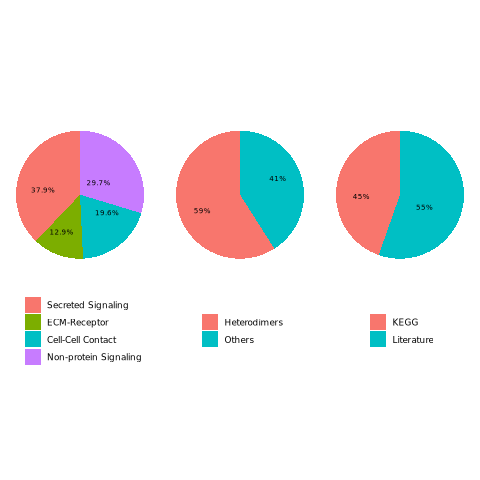

In [27]:
%%R
library(CellChat)
library(patchwork)
CellChatDB <- CellChatDB.mouse # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)


In [65]:
%%R

dplyr::glimpse(CellChatDB$interaction)


Rows: 3,379
Columns: 28
$ interaction_name         <chr> "TGFB1_TGFBR1_TGFBR2", "TGFB2_TGFBR1_TGFBR2",~
$ pathway_name             <chr> "TGFb", "TGFb", "TGFb", "TGFb", "TGFb", "TGFb~
$ ligand                   <chr> "Tgfb1", "Tgfb2", "Tgfb3", "Tgfb1", "Tgfb1", ~
$ receptor                 <chr> "TGFbR1_R2", "TGFbR1_R2", "TGFbR1_R2", "ACVR1~
$ agonist                  <chr> "TGFb agonist", "TGFb agonist", "TGFb agonist~
$ antagonist               <chr> "TGFb antagonist", "TGFb antagonist", "TGFb a~
$ co_A_receptor            <chr> "", "", "", "", "", "", "", "", "", "", "", "~
$ co_I_receptor            <chr> "TGFb inhibition receptor", "TGFb inhibition ~
$ annotation               <chr> "Secreted Signaling", "Secreted Signaling", "~
$ interaction_name_2       <chr> "Tgfb1 - (Tgfbr1+Tgfbr2)", "Tgfb2  - (Tgfbr1+~
$ evidence                 <chr> "KEGG: mmu04350", "KEGG: mmu04350", "KEGG: mm~
$ is_neurotransmitter      <chr> "FALSE", "FALSE", "FALSE", "FALSE", "FALSE", ~
$ ligand.symbol 

In [15]:

data.input <- Integrated_sc[["RNA"]]$data # normalized data matrix
# For Seurat version >= “5.0.0”, get the normalized data via `seurat_object[["RNA"]]$data`
Idents(Integrated_sc) <- "SingleR.labels"
labels <- Idents(Integrated_sc)
meta <- data.frame(labels = labels, row.names = names(labels)) # create a dataframe of the cell labels

In [84]:
%%R
unique(Unintegrated_sc@meta.data$sampleid)

[1] LPS_24H LPS_4H  LPS_1H  NT_0H  
Levels: NT_0H LPS_1H LPS_4H LPS_24H


In [116]:
%%R

NT_0H_unitegrated <- subset(Unintegrated_sc, subset = sampleid %in% c("NT_0H"))
LPS_1H_unitegrated <- subset(Unintegrated_sc, subset = sampleid %in% c("LPS_1H"))
LPS_4H_unitegrated <- subset(Unintegrated_sc, subset = sampleid %in% c("LPS_4H"))
LPS_24H_unitegrated <- subset(Unintegrated_sc, subset = sampleid %in% c("LPS_24H"))


In [87]:
%%R
data.input <- NT_0H_unitegrated[["RNA"]]$data 
Idents(NT_0H_unitegrated) <- "SingleR.labels"
labels <- Idents(NT_0H_unitegrated)
meta <- data.frame(labels = labels, row.names = names(labels)) 

cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")
CellChatDB <- CellChatDB.mouse
CellChatDB.use <- subsetDB(CellChatDB) # all except non-protein signalling
cellchat@DB <- CellChatDB.use

cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)
cellchat <- computeCommunProb(cellchat, type = "triMean")
cellchat <- filterCommunication(cellchat, min.cells = 10)
cellchat <- computeCommunProbPathway(cellchat)
cellchat <- aggregateNet(cellchat)

saveRDS("cellchat_NT0H.rds")

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Macrophages, NKT, B cells, Monocytes, T cells, Tgd, NK cells, DC, Neutrophils, Mast cells, ILC, Stem cells, Basophils 
  |                                                  | 0 % ~calculating   |+                                                 | 1 % ~00s           |++                                                | 2 % ~00s           |++                                                | 4 % ~00s           |+++                                               | 5 % ~00s           |+++                                               | 6 % ~00s           |++++                                              | 7 % ~00s           |+++++                                             | 8 % ~00s           |+++++                                             | 9 % ~00s           |++++++                                            | 11% ~00s           |++++++     

RInterpreterError: Failed to parse and evaluate line 'data.input <- NT_0H_unitegrated[["RNA"]]$data \nIdents(NT_0H_unitegrated) <- "SingleR.labels"\nlabels <- Idents(NT_0H_unitegrated)\nmeta <- data.frame(labels = labels, row.names = names(labels)) \n\ncellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")\nCellChatDB <- CellChatDB.mouse\nCellChatDB.use <- subsetDB(CellChatDB) # all except non-protein signalling\ncellchat@DB <- CellChatDB.use\n\ncellchat <- subsetData(cellchat) # This step is necessary even if using the whole database\ncellchat <- identifyOverExpressedGenes(cellchat)\ncellchat <- identifyOverExpressedInteractions(cellchat)\ncellchat <- computeCommunProb(cellchat, type = "triMean")\ncellchat <- filterCommunication(cellchat, min.cells = 10)\ncellchat <- computeCommunProbPathway(cellchat)\ncellchat <- aggregateNet(cellchat)\n\ncellchat<-saveRDS("cellchat_NT0H.rds")\n'.
R error message: 'Error in saveRDS("cellchat_NT0H.rds") : \'file\' must be no

In [88]:
%%R
cellchat_NT0H<-cellchat
saveRDS(cellchat,"cellchat_NT0H.rds")

In [89]:
%%R

data.input <- LPS_1H_unitegrated[["RNA"]]$data 
Idents(LPS_1H_unitegrated) <- "SingleR.labels"
labels <- Idents(LPS_1H_unitegrated)
meta <- data.frame(labels = labels, row.names = names(labels)) 

cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")
CellChatDB <- CellChatDB.mouse
CellChatDB.use <- subsetDB(CellChatDB) # all except non-protein signalling
cellchat@DB <- CellChatDB.use

cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)
cellchat <- computeCommunProb(cellchat, type = "triMean")
cellchat <- filterCommunication(cellchat, min.cells = 10)
cellchat <- computeCommunProbPathway(cellchat)
cellchat_LPS1H <- aggregateNet(cellchat)

saveRDS(cellchat_LPS1H,"cellchat_LPS1H.rds")

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Macrophages, DC, T cells, Tgd, NKT, ILC, Mast cells, NK cells, Monocytes, Neutrophils, Stromal cells 
  |                                                  | 0 % ~calculating   |+                                                 | 1 % ~01s           |++                                                | 2 % ~00s           |++                                                | 4 % ~00s           |+++                                               | 5 % ~00s           |+++                                               | 6 % ~00s           |++++                                              | 7 % ~00s           |+++++                                             | 8 % ~00s           |+++++                                             | 9 % ~00s           |++++++                                            | 11% ~00s           |++++++             

  |======================================================================| 100%


In [90]:
%%R

data.input <- LPS_4H_unitegrated[["RNA"]]$data 
Idents(LPS_4H_unitegrated) <- "SingleR.labels"
labels <- Idents(LPS_4H_unitegrated)
meta <- data.frame(labels = labels, row.names = names(labels)) 

cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")
CellChatDB <- CellChatDB.mouse
CellChatDB.use <- subsetDB(CellChatDB) # all except non-protein signalling
cellchat@DB <- CellChatDB.use

cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)
cellchat <- computeCommunProb(cellchat, type = "triMean")
cellchat <- filterCommunication(cellchat, min.cells = 10)
cellchat <- computeCommunProbPathway(cellchat)
cellchat_LPS4H <- aggregateNet(cellchat)

saveRDS(cellchat_LPS4H,"cellchat_LPS4H.rds")

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Macrophages, T cells, Monocytes, DC, ILC, NKT, NK cells, Mast cells, Tgd, Neutrophils, Stem cells, Fibroblasts 
  |                                                  | 0 % ~calculating   |+                                                 | 1 % ~01s           |++                                                | 2 % ~00s           |++                                                | 4 % ~00s           |+++                                               | 5 % ~00s           |+++                                               | 6 % ~00s           |++++                                              | 7 % ~00s           |+++++                                             | 8 % ~00s           |+++++                                             | 9 % ~00s           |++++++                                            | 11% ~00s           |++++++   

  |======================================================================| 100%


In [91]:
%%R

data.input <- LPS_24H_unitegrated[["RNA"]]$data 
Idents(LPS_24H_unitegrated) <- "SingleR.labels"
labels <- Idents(LPS_24H_unitegrated)
meta <- data.frame(labels = labels, row.names = names(labels)) 

cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")
CellChatDB <- CellChatDB.mouse
CellChatDB.use <- subsetDB(CellChatDB) # all except non-protein signalling
cellchat@DB <- CellChatDB.use

cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)
cellchat <- computeCommunProb(cellchat, type = "triMean")
cellchat <- filterCommunication(cellchat, min.cells = 10)
cellchat <- computeCommunProbPathway(cellchat)
cellchat_LPS24H <- aggregateNet(cellchat)

saveRDS(cellchat_LPS24H,"cellchat_LPS24H.rds")

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Macrophages, Neutrophils, NK cells, T cells, Monocytes, DC, ILC, NKT, Tgd, Mast cells, Basophils 
  |                                                  | 0 % ~calculating   |+                                                 | 1 % ~00s           |++                                                | 2 % ~00s           |++                                                | 4 % ~00s           |+++                                               | 5 % ~00s           |+++                                               | 6 % ~00s           |++++                                              | 7 % ~00s           |+++++                                             | 8 % ~00s           |+++++                                             | 9 % ~00s           |++++++                                            | 11% ~00s           |++++++                 

  |======================================================================| 100%


In [93]:
%%R
cellchat_LPS24H<-readRDS("cellchat_LPS24H.rds")
cellchat_LPS4H<-readRDS("cellchat_LPS4H.rds")
cellchat_LPS1H<-readRDS("cellchat_LPS1H.rds")
cellchat_NT0H<-readRDS("cellchat_NT0H.rds")
object.list <- list(
  NT_0H = cellchat_NT0H,
  LPS_1H = cellchat_LPS1H,
  LPS_4H = cellchat_LPS4H,
  LPS_24H = cellchat_LPS24H
)

# Compare dimensions of the interaction matrices
lapply(object.list, function(x) dim(x@net$count))
# If these are not identical → liftCellChat() is needed

# Step 1: Check which cell types exist in each condition
lapply(object.list, function(x) levels(x@idents))

# Step 2: Find common cell types across ALL conditions
common_cells <- Reduce(intersect, lapply(object.list, function(x) levels(x@idents)))
message("Common cell types: ", paste(common_cells, collapse = ", "))


Common cell types: Macrophages, NKT, B cells, Monocytes, T cells, Tgd, NK cells, DC, Neutrophils, Mast cells, ILC


In [94]:
%%R
# ============================================================
# FIX: Rename cell types — replace spaces with underscores
# ============================================================

clean_names <- function(x) {
  # Rename idents
  new_labels <- gsub(" ", "_", levels(x@idents))
  levels(x@idents) <- new_labels
  
  # Rename net matrices (rows and cols)
  if (!is.null(x@net$count)) {
    rownames(x@net$count) <- gsub(" ", "_", rownames(x@net$count))
    colnames(x@net$count) <- gsub(" ", "_", colnames(x@net$count))
  }
  if (!is.null(x@net$weight)) {
    rownames(x@net$weight) <- gsub(" ", "_", rownames(x@net$weight))
    colnames(x@net$weight) <- gsub(" ", "_", colnames(x@net$weight))
  }
  
  # Rename netP pathway-level matrices
  if (!is.null(x@netP$prob)) {
    dimnames(x@netP$prob)[[1]] <- gsub(" ", "_", dimnames(x@netP$prob)[[1]])
    dimnames(x@netP$prob)[[2]] <- gsub(" ", "_", dimnames(x@netP$prob)[[2]])
  }
  
  return(x)
}

object.list <- lapply(object.list, clean_names)

# Verify names are clean
lapply(object.list, function(x) levels(x@idents))
# Should now show: "B_cells", "T_cells", "NK_cells", "Mast_cells" etc.


$NT_0H
 [1] "Macrophages" "NKT"         "B_cells"     "Monocytes"   "T_cells"    
 [6] "Tgd"         "NK_cells"    "DC"          "Neutrophils" "Mast_cells" 
[11] "ILC"         "Stem_cells"  "Basophils"  

$LPS_1H
 [1] "B_cells"       "Macrophages"   "DC"            "T_cells"      
 [5] "Tgd"           "NKT"           "ILC"           "Mast_cells"   
 [9] "NK_cells"      "Monocytes"     "Neutrophils"   "Stromal_cells"

$LPS_4H
 [1] "B_cells"     "Macrophages" "T_cells"     "Monocytes"   "DC"         
 [6] "ILC"         "NKT"         "NK_cells"    "Mast_cells"  "Tgd"        
[11] "Neutrophils" "Stem_cells"  "Fibroblasts"

$LPS_24H
 [1] "B_cells"     "Macrophages" "Neutrophils" "NK_cells"    "T_cells"    
 [6] "Monocytes"   "DC"          "ILC"         "NKT"         "Tgd"        
[11] "Mast_cells"  "Basophils"  



In [95]:
%%R

# ============================================================
# Now get common/all cell types and run liftCellChat safely
# ============================================================

all_cells   <- Reduce(union,     lapply(object.list, function(x) levels(x@idents)))
common_cells <- Reduce(intersect, lapply(object.list, function(x) levels(x@idents)))

message("All cell types:    ", paste(all_cells, collapse = ", "))
message("Common cell types: ", paste(common_cells, collapse = ", "))

# liftCellChat now works without the array replacement error
object.list <- lapply(object.list, function(x) {
  liftCellChat(x, group.new = all_cells)
})

# Verify all dimensions now match
lapply(object.list, function(x) dim(x@net$count))
# Should all be identical, e.g. [1] 13 13


Update slots object@net, object@netP, object@idents in a single dataset... 
Update slots object@net, object@netP, object@idents in a single dataset... 
Update slots object@net, object@netP, object@idents in a single dataset... 
Update slots object@net, object@netP, object@idents in a single dataset... 
$NT_0H
[1] 15 15

$LPS_1H
[1] 15 15

$LPS_4H
[1] 15 15

$LPS_24H
[1] 15 15



All cell types:    Macrophages, NKT, B_cells, Monocytes, T_cells, Tgd, NK_cells, DC, Neutrophils, Mast_cells, ILC, Stem_cells, Basophils, Stromal_cells, Fibroblasts
Common cell types: Macrophages, NKT, B_cells, Monocytes, T_cells, Tgd, NK_cells, DC, Neutrophils, Mast_cells, ILC
The CellChat object will be lifted up using the cell labels Macrophages, NKT, B_cells, Monocytes, T_cells, Tgd, NK_cells, DC, Neutrophils, Mast_cells, ILC, Stem_cells, Basophils, Stromal_cells, Fibroblasts
The CellChat object will be lifted up using the cell labels Macrophages, NKT, B_cells, Monocytes, T_cells, Tgd, NK_cells, DC, Neutrophils, Mast_cells, ILC, Stem_cells, Basophils, Stromal_cells, Fibroblasts
The CellChat object will be lifted up using the cell labels Macrophages, NKT, B_cells, Monocytes, T_cells, Tgd, NK_cells, DC, Neutrophils, Mast_cells, ILC, Stem_cells, Basophils, Stromal_cells, Fibroblasts
The CellChat object will be lifted up using the cell labels Macrophages, NKT, B_cells, Monocytes, T_cel

In [96]:
%%R
# ============================================================
# Re-merge and continue analysis
# ============================================================

cellchat_merged <- mergeCellChat(object.list, add.names = names(object.list))
message("Merge successful — ready for differential analysis")


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.
Merge successful <U+2014> ready for differential analysis


In [ ]:
%%R
# Output directory — change path as needed
out_dir <- "./cellchat_pdf_output"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)


# ============================================================
# 1. GLOBAL INTERACTION COUNT & STRENGTH
# ============================================================

pdf(file.path(out_dir, "01_global_interaction_comparison.pdf"),
    width = 10, height = 5)

p1 <- compareInteractions(cellchat_merged, show.legend = FALSE,
                           group = c(1,2,3,4), measure = "count")
p2 <- compareInteractions(cellchat_merged, show.legend = FALSE,
                           group = c(1,2,3,4), measure = "weight")
print(p1 + p2)

dev.off()
message("Saved: 01_global_interaction_comparison.pdf")


# ============================================================
# 2. DIFFERENTIAL INTERACTION CIRCLE PLOTS
# ============================================================

pdf(file.path(out_dir, "02_differential_interaction_circles.pdf"),
    width = 18, height = 6)

par(mfrow = c(1, 3))

netVisual_diffInteraction(cellchat_merged, weight.scale = TRUE,
                          comparison = c(1, 2),
                          title.name = "LPS_1H vs NT_0H (count)")

netVisual_diffInteraction(cellchat_merged, weight.scale = TRUE,
                          comparison = c(1, 3),
                          title.name = "LPS_4H vs NT_0H (count)")

netVisual_diffInteraction(cellchat_merged, weight.scale = TRUE,
                          comparison = c(1, 4),
                          title.name = "LPS_24H vs NT_0H (count)")

dev.off()
message("Saved: 02_differential_interaction_circles.pdf")


# ============================================================
# 3. DIFFERENTIAL INTERACTION HEATMAPS (STRENGTH)
# ============================================================

pdf(file.path(out_dir, "03_differential_interaction_heatmaps.pdf"),
    width = 18, height = 6)

par(mfrow = c(1, 3))

netVisual_diffInteraction(cellchat_merged, weight.scale = TRUE,
                          measure = "weight", comparison = c(1, 2),
                          title.name = "LPS_1H vs NT_0H (strength)")

netVisual_diffInteraction(cellchat_merged, weight.scale = TRUE,
                          measure = "weight", comparison = c(1, 3),
                          title.name = "LPS_4H vs NT_0H (strength)")

netVisual_diffInteraction(cellchat_merged, weight.scale = TRUE,
                          measure = "weight", comparison = c(1, 4),
                          title.name = "LPS_24H vs NT_0H (strength)")

dev.off()
message("Saved: 03_differential_interaction_heatmaps.pdf")


In [76]:
%%R
str(cellchat_merged)

Formal class 'CellChat' [package "CellChat"] with 15 slots
  ..@ data.raw      : num[0 , 0 ] 
  ..@ data          : num[0 , 0 ] 
  ..@ data.signaling:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:3610113] 21 33 45 56 57 59 65 66 74 78 ...
  .. .. ..@ p       : int [1:43654] 0 106 232 284 375 410 456 501 573 707 ...
  .. .. ..@ Dim     : int [1:2] 1016 43653
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:1016] "Il17a" "Il17f" "Col9a1" "Cfc1" ...
  .. .. .. ..$ : chr [1:43653] "AAACAAGCAACTGTTCAGTGAGTG-7" "AAACCAATCCCGCTGAAGTGAGTG-7" "AAACCAATCTTTGGATAGTGAGTG-7" "AAACCGGTCAATCGCCAGTGAGTG-7" ...
  .. .. ..@ x       : num [1:3610113] 5.842 0.919 3.096 1.709 1.39 ...
  .. .. ..@ factors : list()
  ..@ data.scale    : num[0 , 0 ] 
  ..@ data.smooth   : num[0 , 0 ] 
  ..@ images        :List of 4
  .. ..$ NT_0H  : list()
  .. ..$ LPS_1H : list()
  .. ..$ LPS_4H : list()
  .. ..$ LPS_24H: list()
  ..@ net           :List of 4
  .. ..$ NT_0H  :Lis

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ hub              : Named num [1:15] 0 0 0 0 0 0 0 0 0 1 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ authority        : Named num [1:15] 1 0 0.106 0.738 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ eigen            : Named num [1:15] 7.01e-01 7.37e-18 7.44e-02 5.17e-01 7.37e-18 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ page_rank        : Named num [1:15] 0.0942 0.0722 0.0745 0.0885 0.0722 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ betweenness      : Named num [1:15] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



authority        : Named num [1:15] 0.707 0.558 0.659 0.625 0.851 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ eigen            : Named num [1:15] 0.45 0.588 0.594 0.892 0.867 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ page_rank        : Named num [1:15] 0.0917 0.075 0.0863 0.0825 0.1079 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ betweenness      : Named num [1:15] 0 0 0 0 0 0 0 5 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ flowbet          : Named num [1:15] 3.3 4.62 4.47 6.93 6.43 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ info             : Named num [1:15] 0.0975 0.0885 0.0946 0.1042 0.1076 ...
  .. .. .. .. .. .

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



$ flowbet          : Named num [1:15] 0 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ info             : Named num [1:15] 0 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. ..$ AGRN      :List of 11
  .. .. .. .. ..$ outdeg_unweighted: Named num [1:15] 0 0 0 0 0 0 2 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ indeg_unweighted : Named num [1:15] 0 1 0 0 0 1 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ outdeg           : Named num [1:15] 0 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ indeg            : Named num [1:15] 0 0.0156 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "N

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



$ info             : Named num [1:15] 0 0 0 0 0 0 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. ..$ OSM       :List of 11
  .. .. .. .. ..$ outdeg_unweighted: Named num [1:15] 0 1 0 0 0 1 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ indeg_unweighted : Named num [1:15] 0 0 0 0 0 2 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ outdeg           : Named num [1:15] 0 0.000835 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ indeg            : Named num [1:15] 0 0 0 0 0 ...
  .. .. .. .. .. ..- attr(*, "names")= chr [1:15] "Macrophages" "NKT" "B_cells" "Monocytes" ...
  .. .. .. .. ..$ hub              : Named num [1:15] 6.16e-17 6.12e-01 6.16e-17 6.16e-17 6.16e-17 ...
  .. .. .. .. .. ..

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [78]:
%%R
pdf(file.path(out_dir, "02_differential_interaction_circles_specific.pdf"),
    width = 18, height = 6)

par(mfrow = c(1, 3))

netVisual_diffInteraction(
  cellchat_merged,
  weight.scale = TRUE,
  comparison = c(1, 2),
  sources.use = c("Macrophages"),   # change to your exact macrophage label
 # targets.use = c("T_cells"),        # change to your exact T cell label(s)
  title.name = "LPS_1H vs NT_0H (Mac → T, count)"
)

netVisual_diffInteraction(
  cellchat_merged,
  weight.scale = TRUE,
  comparison = c(1, 3),
  sources.use = c("Macrophages"),
 # targets.use = c("T_cells"),
  title.name = "LPS_4H vs NT_0H (Mac → T, count)"
)

netVisual_diffInteraction(
  cellchat_merged,
  weight.scale = TRUE,
  comparison = c(1, 4),
  sources.use = c("Macrophages"),
 # targets.use = c("T_cells"),
  title.name = "LPS_24H vs NT_0H (Mac → T, count)"
)

dev.off()
message("Saved: 02_differential_interaction_circles.pdf")

Saved: 02_differential_interaction_circles.pdf


In [58]:
%%R

# ============================================================
# 4. INTERACTION HEATMAPS — ALL CONDITIONS (FIXED)
# ============================================================

pdf(file.path(out_dir, "04_interaction_heatmap_all_conditions.pdf"),
    width = 16, height = 7)

# ComplexHeatmap objects must be drawn separately — cannot use patchwork +
# Use draw() with padding to place side by side on the same page

h1 <- netVisual_heatmap(cellchat_merged,
                         comparison = c(1, 2, 3, 4),
                         measure = "count",
                         title.name = "Interaction Count")

h2 <- netVisual_heatmap(cellchat_merged,
                         comparison = c(1, 2, 3, 4),
                         measure = "weight",
                         title.name = "Interaction Strength")

# Draw side by side using ComplexHeatmap concatenation operator
draw(h1 + h2,                          # ComplexHeatmap's own + operator
     ht_gap = unit(1, "cm"),
     heatmap_legend_side = "right",
     annotation_legend_side = "right")

dev.off()
message("Saved: 04_interaction_heatmap_all_conditions.pdf")



Do heatmap based on a merged object 

Do heatmap based on a merged object 

Saved: 04_interaction_heatmap_all_conditions.pdf


In [69]:
%%R
# ============================================================
# 5. PATHWAY INFORMATION FLOW (rankNet)
# ============================================================

pdf(file.path(out_dir, "05_pathway_rankNe12.pdf"),
    width = 12, height = 8)

rankNet(cellchat_merged, mode = "comparison", stacked = TRUE,
        do.stat = TRUE, comparison = c(1,2))


In [70]:
%%R
pdf(file.path(out_dir, "05_pathway_rankNet_13.pdf"),
    width = 12, height = 8)

rankNet(cellchat_merged, mode = "comparison", stacked = TRUE,
        do.stat = TRUE, comparison = c(1,3))


In [71]:
%%R
pdf(file.path(out_dir, "05_pathway_rankNet_14.pdf"),
    width = 12, height = 8)
rankNet(cellchat_merged, mode = "comparison", stacked = TRUE,
        do.stat = TRUE, comparison = c(1,4))

In [87]:
%%R
pdf(file.path(out_dir, "Signalling_changes_0vs1.pdf"),
    width = 24, height = 10)
gg1 <- netAnalysis_signalingChanges_scatter(cellchat_merged, idents.use = "Macrophages")
#> Visualizing differential outgoing and incoming signaling changes from NL to LS
#> The following `from` values were not present in `x`: 0
#> The following `from` values were not present in `x`: 0, -1
gg2 <- netAnalysis_signalingChanges_scatter(cellchat_merged, idents.use = "T_cells")
#> Visualizing differential outgoing and incoming signaling changes from NL to LS
#> The following `from` values were not present in `x`: 0, 2
#> The following `from` values were not present in `x`: 0, -1
patchwork::wrap_plots(plots = list(gg1,gg2))

Visualizing differential outgoing and incoming signaling changes from NT_0H to LPS_1H
Visualizing differential outgoing and incoming signaling changes from NT_0H to LPS_1H


In [108]:
%%R
# Compute centrality for all objects in object.list
for (i in seq_along(object.list)) {
  object.list[[i]] <- netAnalysis_computeCentrality(object.list[[i]], slot.name = "netP")
}

# Now combine pathways and plot
i = 1
pathway.union <- union(object.list[[i]]@netP$pathways,
                       object.list[[i+1]]@netP$pathways)

pdf(file.path(out_dir, "Heatmap_similarity_comparison_LPS_0vs4.pdf"),
    width = 10, height = 10)
ht1 = netAnalysis_signalingRole_heatmap(
  object.list[[i]],
  pattern = "outgoing",
  signaling = pathway.union,
  title = names(object.list)[i],
  width = 5, height = 6
)

ht2 = netAnalysis_signalingRole_heatmap(
  object.list[[i+2]],
  pattern = "outgoing",
  signaling = pathway.union,
  title = names(object.list)[i+2],
  width = 5, height = 6
)

ht1+ht2

In [ ]:
%%R

# Set maximum size to 2 GB (or more if needed)
options(future.globals.maxSize = 2 * 1024^3)  # 2 GB
library(CellChat)
library(ComplexHeatmap)

# List of your Seurat objects
datasets <- list(
  NT_0H    = NT_0H_unitegrated,
  LPS_1H   = LPS_1H_unitegrated,
  LPS_4H   = LPS_4H_unitegrated,
  LPS_24H  = LPS_24H_unitegrated
)
object.list <- list()  # To store processed CellChat objects

for (name in names(datasets)) {
  
  seurat_obj <- datasets[[name]]
  Idents(seurat_obj) <- "SingleR.labels"

  # Drop unused factor levels in metadata
  labels <- droplevels(Idents(seurat_obj))
  meta <- data.frame(labels = labels, row.names = names(labels))
  
  # Create CellChat object
  cellchat <- createCellChat(
    object = seurat_obj[["RNA"]]$data,
    meta = meta,
    group.by = "labels"
  )
  
  # Use mouse CellChatDB
  CellChatDB.use <- subsetDB(CellChatDB.mouse)  # remove non-protein signaling if desired
  cellchat@DB <- CellChatDB.use
  
  # Subset data, identify overexpressed genes/interactions
  cellchat <- subsetData(cellchat)
  cellchat <- identifyOverExpressedGenes(cellchat)
  cellchat <- identifyOverExpressedInteractions(cellchat)
  
  # Compute communication probability using triMean
  cellchat <- computeCommunProb(cellchat, type = "triMean")
  
  # Filter out low-cell interactions
  cellchat <- filterCommunication(cellchat, min.cells = 10)
  
  # Compute pathway-level probabilities and aggregate network
  cellchat <- computeCommunProbPathway(cellchat)
  cellchat <- aggregateNet(cellchat)
  
  # Store processed object
  object.list[[name]] <- cellchat
}

# Merge all CellChat objects
cellchat_merged <- mergeCellChat(object.list, add.names = names(object.list))

# Compute network centrality (needed for heatmaps or role analysis)
cellchat_merged <- netAnalysis_computeCentrality(cellchat_merged, slot.name = "netP")

# Compute functional similarity, embedding, and clustering
cellchat_merged <- computeNetSimilarityPairwise(cellchat_merged, type = "functional", slot.name = "netP")
cellchat_merged <- netEmbedding(cellchat_merged, type = "functional", slot.name = "netP")
cellchat_merged <- netClustering(cellchat_merged, type = "functional", slot.name = "netP")

# Plot functional similarity embedding
pdf(file.path(out_dir, "Functional_similarity_based_changes.pdf"), width = 24, height = 10)
netVisual_embeddingPairwise(cellchat_merged, type = "functional", label.size = 3.5)
dev.off()
message("Saved: Functional_similarity_based_changes.pdf")


[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Macrophages, NKT, B cells, Monocytes, T cells, Tgd, NK cells, DC, Neutrophils, Mast cells, ILC, Stem cells, Basophils 
The number of highly variable ligand-receptor pairs used for signaling inference is 1048 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-03-25 17:23:47.679353]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-03-25 17:53:50.241069]"
The cell-cell communication related with the following cell groups are excluded due to the few number of cells:  Neutrophils, ILC, Stem cells, Basophils ! 	49.4% interactions are removed!
[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Macrophages, DC, 

In [77]:
%%R

# ============================================================
# 6. 2D MANIFOLD EMBEDDING OF SIGNALING PATTERNS
# ============================================================
# Ensure merged object has netP computed
cellchat_merged <- netAnalysis_computeCentrality(cellchat_merged, slot.name = "netP")
cellchat_merged <- aggregateNet(cellchat_merged)

# Compute similarity (explicit slot)
cellchat_merged <- computeNetSimilarityPairwise(
  cellchat_merged,
  type = "functional",
  slot.name = "netP"
)

# Embedding
cellchat_merged <- netEmbedding(
  cellchat_merged,
  type = "functional",
  slot.name = "netP"
)

# Clustering
cellchat_merged <- netClustering(
  cellchat_merged,
  type = "functional",
  slot.name = "netP"
)

# Plot
pdf(file.path(out_dir, "06_signaling_manifold_embedding.pdf"),
    width = 15, height = 15)

netVisual_embeddingPairwise(
  cellchat_merged,
  type = "functional",
  label.size = 3.5
)

netVisual_embeddingPairwiseZoomIn(
  cellchat_merged,
  type = "functional",
  nCol = 2
)

dev.off()
message("Saved: 06_signaling_manifold_embedding.pdf")


Error in base::rowSums(x, na.rm = na.rm, dims = dims, ...) : 
  'x' must be an array of at least two dimensions


RInterpreterError: Failed to parse and evaluate line '\n# ============================================================\n# 6. 2D MANIFOLD EMBEDDING OF SIGNALING PATTERNS\n# ============================================================\n# Ensure merged object has netP computed\ncellchat_merged <- netAnalysis_computeCentrality(cellchat_merged, slot.name = "netP")\ncellchat_merged <- aggregateNet(cellchat_merged)\n\n# Compute similarity (explicit slot)\ncellchat_merged <- computeNetSimilarityPairwise(\n  cellchat_merged,\n  type = "functional",\n  slot.name = "netP"\n)\n\n# Embedding\ncellchat_merged <- netEmbedding(\n  cellchat_merged,\n  type = "functional",\n  slot.name = "netP"\n)\n\n# Clustering\ncellchat_merged <- netClustering(\n  cellchat_merged,\n  type = "functional",\n  slot.name = "netP"\n)\n\n# Plot\npdf(file.path(out_dir, "06_signaling_manifold_embedding.pdf"),\n    width = 12, height = 6)\n\nnetVisual_embeddingPairwise(\n  cellchat_merged,\n  type = "functional",\n  label.siz

In [57]:
%%R


# ============================================================
# 7. PATHWAY SIMILARITY RANKING
# ============================================================

pdf(file.path(out_dir, "07_pathway_similarity_ranking.pdf"),
    width = 10, height = 8)

rankSimilarity(cellchat_merged, type = "functional")

dev.off()
message("Saved: 07_pathway_similarity_ranking.pdf")


# ============================================================
# 8. BUBBLE PLOT — LIGAND-RECEPTOR PAIRS
# ============================================================

pdf(file.path(out_dir, "08_bubble_plot_LR_pairs.pdf"),
    width = 18, height = 10)

# All cell types
netVisual_bubble(cellchat_merged,
                 sources.use = NULL,
                 targets.use = NULL,
                 comparison = c(1,2,3,4),
                 angle.x = 45,
                 remove.isolate = TRUE,
                 title.name = "All L-R Pairs Across Conditions")

dev.off()
message("Saved: 08_bubble_plot_LR_pairs.pdf")


# ============================================================
# 9. CHORD DIAGRAMS — PATHWAY ACROSS CONDITIONS
# ============================================================

# Get pathways present in all conditions
all_pathways <- Reduce(intersect, lapply(object.list, function(x) x@netP$pathways))
message("Pathways in all conditions: ", paste(all_pathways, collapse = ", "))

# Save one PDF per pathway (or limit to top pathways)
top_pathways <- all_pathways[1:min(10, length(all_pathways))]  # top 10 max

for (pw in top_pathways) {
  pdf(file.path(out_dir, paste0("09_chord_", pw, ".pdf")),
      width = 14, height = 14)
  
  par(mfrow = c(2, 2))
  for (i in 1:4) {
    tryCatch({
      netVisual_aggregate(object.list[[i]],
                          signaling = pw,
                          layout = "chord",
                          title.name = paste(names(object.list)[i], "-", pw))
    }, error = function(e) {
      plot.new()
      title(main = paste(names(object.list)[i], "-", pw, "\n(not detected)"))
    })
  }
  
  dev.off()
  message("Saved: 09_chord_", pw, ".pdf")
}


# ============================================================
# 10. NMF SIGNALING PATTERNS (OUTGOING & INCOMING)
# ============================================================

# -- Outgoing patterns --
pdf(file.path(out_dir, "10a_selectK_outgoing.pdf"), width = 8, height = 5)
selectK(cellchat_merged, pattern = "outgoing")
dev.off()

# Inspect the selectK plot and set nPatterns_out accordingly
nPatterns_out <- 4  # <-- adjust after reviewing selectK output

cellchat_merged <- identifyCommunicationPatterns(
  cellchat_merged, pattern = "outgoing", k = nPatterns_out, height = 18
)

pdf(file.path(out_dir, "10b_outgoing_patterns.pdf"), width = 12, height = 8)
netAnalysis_river(cellchat_merged, pattern = "outgoing")
netAnalysis_dot(cellchat_merged, pattern = "outgoing")
dev.off()
message("Saved: 10b_outgoing_patterns.pdf")

# -- Incoming patterns --
pdf(file.path(out_dir, "10c_selectK_incoming.pdf"), width = 8, height = 5)
selectK(cellchat_merged, pattern = "incoming")
dev.off()

nPatterns_in <- 4  # <-- adjust after reviewing selectK output

cellchat_merged <- identifyCommunicationPatterns(
  cellchat_merged, pattern = "incoming", k = nPatterns_in, height = 18
)

pdf(file.path(out_dir, "10d_incoming_patterns.pdf"), width = 12, height = 8)
netAnalysis_river(cellchat_merged, pattern = "incoming")
netAnalysis_dot(cellchat_merged, pattern = "incoming")
dev.off()
message("Saved: 10d_incoming_patterns.pdf")




Compute signaling network similarity for datasets 1 2 3 4 
Manifold learning of the signaling networks for datasets 1 2 3 4 


/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Classification learning of the signaling networks for datasets 1 2 3 4 


During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


Saved: 01_global_interaction_comparison.pdf
Saved: 02_differential_interaction_circles.pdf
Saved: 03_differential_interaction_heatmaps.pdf
Do heatmap based on a merged object 

Do heatmap based on a merged object 

Saved: 04_interaction_heatmap_all_conditions.pdf
The text on the y-axis will not be colored for the number of compared datasets larger than 3!
The text on the y-axis will not be colored for the number of compared datasets larger than 3!
Saved: 05_pathway_rankNet.pdf
Error in eval(substitute(expr), data, enclos = parent.frame()) : 
  argument is missing, with no default


RInterpreterError: Failed to parse and evaluate line '\n# Output directory — change path as needed\nout_dir <- "./cellchat_pdf_output"\ndir.create(out_dir, showWarnings = FALSE, recursive = TRUE)\n\n\n# ============================================================\n# 1. GLOBAL INTERACTION COUNT & STRENGTH\n# ============================================================\n\npdf(file.path(out_dir, "01_global_interaction_comparison.pdf"),\n    width = 10, height = 5)\n\np1 <- compareInteractions(cellchat_merged, show.legend = FALSE,\n                           group = c(1,2,3,4), measure = "count")\np2 <- compareInteractions(cellchat_merged, show.legend = FALSE,\n                           group = c(1,2,3,4), measure = "weight")\nprint(p1 + p2)\n\ndev.off()\nmessage("Saved: 01_global_interaction_comparison.pdf")\n\n\n# ============================================================\n# 2. DIFFERENTIAL INTERACTION CIRCLE PLOTS\n# ============================================================\n\npdf

In [68]:
%%R
cellchat <- createCellChat(object = data.input, meta = meta, group.by = "labels")


[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Macrophages, Neutrophils, NK cells, T cells, Monocytes, DC, ILC, NKT, Tgd, Mast cells, Basophils, Stem cells, Fibroblasts, Stromal cells 


In addition: Warning message:
In createCellChat(object = data.input, meta = meta, group.by = "labels") :
  The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 



In [17]:
%%R

cellchat<-readRDS("cellchat.rds")

In [69]:
%%R
CellChatDB <- CellChatDB.mouse
CellChatDB.use <- subsetDB(CellChatDB) # all except non-protein signalling
cellchat@DB <- CellChatDB.use


In [70]:
%%R
cellchat <- subsetData(cellchat) # This step is necessary even if using the whole database
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)

  |                                                  | 0 % ~calculating   |+                                                 | 1 % ~01s           |++                                                | 2 % ~00s           |++                                                | 4 % ~00s           |+++                                               | 5 % ~00s           |+++                                               | 6 % ~00s           |++++                                              | 7 % ~00s           |+++++                                             | 8 % ~00s           |+++++                                             | 9 % ~00s           |++++++                                            | 11% ~00s           |++++++                                            | 12% ~00s           |+++++++                                           | 13% ~00s           |++++++++                                          | 14% ~00s           |++++++++                                          | 15% ~00s 

In [71]:
%%R
cellchat <- identifyOverExpressedGenes(cellchat)
cellchat <- identifyOverExpressedInteractions(cellchat)
cellchat <- computeCommunProb(cellchat, type = "triMean")
cellchat <- filterCommunication(cellchat, min.cells = 10)
cellchat <- computeCommunProbPathway(cellchat)
cellchat <- aggregateNet(cellchat)


triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-03-20 16:37:26.842606]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-03-20 16:51:02.572564]"


  |======================================================================| 100%


In [72]:
%%R
cellchat <- filterCommunication(cellchat, min.cells = 10)
df.net <- subsetCommunication(cellchat)
write.csv(df.net,file="df_net_cellchat.csv")
#df.net.selected <- subsetCommunication(cellchat, sources.use = "Macrophages", targets.use = "T cell")
#gives the inferred cell-cell communications sending from cell groups 1 and 2 to cell groups 4 and 5

#df.net <- subsetCommunication(cellchat, signaling = c("WNT", "TGFb"))
#gives the inferred cell-cell communications mediated by signaling WNT and TGFb.

The cell-cell communication related with the following cell groups are excluded due to the few number of cells:  Basophils, Stem cells, Fibroblasts, Stromal cells ! 	51.3% interactions are removed!


In [73]:
%%R

cellchat <- computeCommunProbPathway(cellchat)
cellchat <- aggregateNet(cellchat)

In [79]:
%%R

ptm = Sys.time()
groupSize <- as.numeric(table(cellchat@idents))
groupNames <- names(table(cellchat@idents))

# Create a named color vector
cols <- jdb_palette("corona")
# Expand if needed
if (length(cols) < length(groupNames)) {
  cols <- colorRampPalette(cols)(length(groupNames))
}
names(cols) <- groupNames  # name each color by cluster/cell type

par(mfrow = c(1,2), xpd=TRUE)
pdf("cellchat_macrophages.pdf", width = 14, height = 7)
netVisual_circle(cellchat@net$count, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Number of interactions", color.use=cols)
netVisual_circle(cellchat@net$weight, vertex.weight = groupSize, weight.scale = T, label.edge= F, title.name = "Interaction weights/strength", color.use=cols)


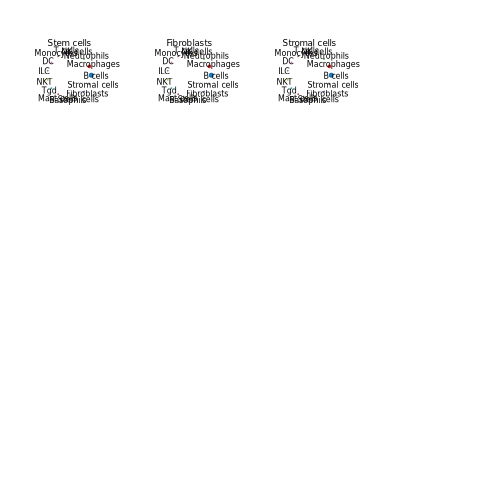

In [76]:
%%R

mat <- cellchat@net$weight
groupSize <- as.numeric(table(cellchat@idents))
groupNames <- names(table(cellchat@idents))

# Create a named color vector
cols <- jdb_palette("corona")
# Expand if needed
if (length(cols) < length(groupNames)) {
  cols <- colorRampPalette(cols)(length(groupNames))
}
names(cols) <- groupNames  # name each color by cluster/cell type

# Plot
#pdf("D24_cite_invitro_cellchat2.pdf", width = 14, height = 14)
par(mfrow = c(3,4), xpd = TRUE)

for (i in 1:nrow(mat)) {
  mat2 <- matrix(0, nrow = nrow(mat), ncol = ncol(mat), dimnames = dimnames(mat))
  mat2[i, ] <- mat[i, ]
  netVisual_circle(
    mat2,
    vertex.weight = groupSize,
    weight.scale = TRUE,
    edge.weight.max = max(mat),
    title.name = rownames(mat)[i],
    color.use = cols  # <- named vector
  )
}



In [80]:
%%R
# Access all significant signaling pathways
pathways.show.all <- cellchat@netP$pathways

# Check group names
groupNames <- levels(cellchat@idents)
vertex.receiver <- seq(1, 5)  # automatically matches your identities

# Define color palette (named vector)
cols <- jdb_palette("corona")
if (length(cols) < length(groupNames)) {
  cols <- colorRampPalette(cols)(length(groupNames))
}
names(cols) <- groupNames

# Create output folder (optional)
dir.create("cellchat_pathway_plots", showWarnings = FALSE)

# Loop through pathways
for (i in seq_along(pathways.show.all)) {
  pathway_name <- pathways.show.all[i]
  
  message("Processing pathway: ", pathway_name)
  
  # Visualize communication network (hierarchical layout)
  pdf(file = paste0("cellchat_pathway_plots/", pathway_name, "_network.png"), 
      width = 6, height = 5)
  netVisual(
    cellchat,
    signaling = pathway_name,
    vertex.receiver = vertex.receiver,
    layout = "hierarchy",
    color.use = cols,           # use custom palette
    label.edge = FALSE,
    vertex.size = 6,
    vertex.label.cex = 0.6
  )
  dev.off()
  
  # Compute and visualize contribution of each L–R pair
  gg <- netAnalysis_contribution(cellchat, signaling = pathway_name)
  
  ggsave(
    filename = paste0("cellchat_pathway_plots/", pathway_name, "_L-R_contribution.png"),
    plot = gg,
    width = 3,
    height = 2,
    units = 'in',
    dpi = 300
  )
}


Processing pathway: ICAM
Processing pathway: ADGRE
Processing pathway: SELPLG
Processing pathway: FN1
Processing pathway: CCL
Processing pathway: GALECTIN
Processing pathway: APP
Processing pathway: THBS
Processing pathway: THY1
Processing pathway: MHC-I
Processing pathway: CD45
Processing pathway: MHC-II
Processing pathway: CLEC
Processing pathway: COMPLEMENT
Processing pathway: SEMA4
Processing pathway: TNF
Processing pathway: CXCL
Processing pathway: CD52
Processing pathway: CD80
Processing pathway: MIF
Processing pathway: ANNEXIN
Processing pathway: TGFb
Processing pathway: CEACAM
Processing pathway: SIRP
Processing pathway: BST2
Processing pathway: CD39
Processing pathway: CD48
Processing pathway: PECAM2
Processing pathway: PECAM1
Processing pathway: VISFATIN
Processing pathway: CD86
Processing pathway: IL16
Processing pathway: SELL
Processing pathway: PLAU
Processing pathway: CD137
Processing pathway: IL2
Processing pathway: IL4
Processing pathway: IFN-II
Processing pathway: LAIR

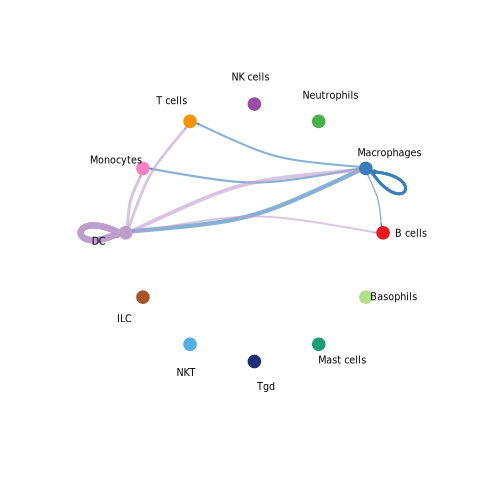

In [24]:
%%R

pathways.show <- c("IL6") 
# Hierarchy plot
# Here we define `vertex.receive` so that the left portion of the hierarchy plot shows signaling to fibroblast and the right portion shows signaling to immune cells 
#vertex.receiver = seq(1,3) # a numeric vector. 
#netVisual_aggregate(cellchat, signaling = pathways.show)
# Circle plot
par(mfrow=c(1,1))
netVisual_aggregate(cellchat_LPS24H, signaling = pathways.show, layout = "circle")
netVisual_aggregate(cellchat_LPS24H, signaling = pathways.show, layout = "circle")
netVisual_aggregate(cellchat_LPS24H, signaling = pathways.show, layout = "circle")
netVisual_aggregate(cellchat_LPS24H, signaling = pathways.show, layout = "circle")

In [ ]:
%%R

netVisual_chord_gene(cellchat, sources.use = c(1,2,3,4), targets.use = c(5:11), slot.name = "netP", legend.pos.x = 10)

In [56]:
%%R

#see all the signals from macrophage to T cells

# show all the significant interactions (L-R pairs) from some cell groups (defined by 'sources.use') to other cell groups (defined by 'targets.use')
# show all the interactions sending from Inflam.FIB
pdf("Macrophage_Tgd_signalling_pathway.pdf", width = 8, height = 8)

netVisual_chord_gene(
  cellchat,
  sources.use = "Macrophages",
  targets.use = "Tgd",
  lab.cex = 0.5,
  legend.pos.y = 30
)



NULL


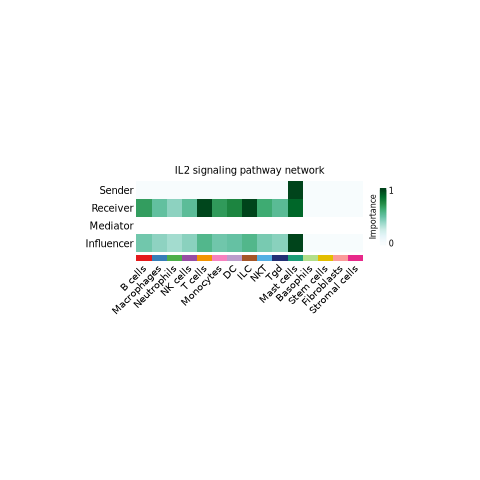

In [35]:
%%R

# Compute the network centrality scores
cellchat <- netAnalysis_computeCentrality(cellchat, slot.name = "netP") # the slot 'netP' means the inferred intercellular communication network of signaling pathways
# Visualize the computed centrality scores using heatmap, allowing ready identification of major signaling roles of cell groups
pathways.show<-"IL2"
p<-netAnalysis_signalingRole_network(cellchat, signaling = pathways.show, width = 8, height = 2.5, font.size = 10)
ggsave(
  filename = "IL2_signalling_pathway.png",
  plot = p,
  width = 8,
  height = 8
)
p

In [26]:
%%R
# Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
gg1 <- netAnalysis_signalingRole_scatter(cellchat_LPS1H)
#> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
# Signaling role analysis on the cell-cell communication networks of interest
gg2 <- netAnalysis_signalingRole_scatter(cellchat_LPS1H, signaling = c("IL6"))
#> Signaling role analysis on the cell-cell communication network from user's input
gg1 + gg2

Error in netAnalysis_signalingRole_scatter(cellchat_LPS1H) : 
  Please run `netAnalysis_computeCentrality` to compute the network centrality scores!


RInterpreterError: Failed to parse and evaluate line '# Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways\ngg1 <- netAnalysis_signalingRole_scatter(cellchat_LPS1H)\n#> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways\n# Signaling role analysis on the cell-cell communication networks of interest\ngg2 <- netAnalysis_signalingRole_scatter(cellchat_LPS1H, signaling = c("IL6"))\n#> Signaling role analysis on the cell-cell communication network from user\'s input\ngg1 + gg2\n'.
R error message: 'Error in netAnalysis_signalingRole_scatter(cellchat_LPS1H) : \n  Please run `netAnalysis_computeCentrality` to compute the network centrality scores!'

In [44]:
%%R


# Create heatmaps for outgoing and incoming signaling roles
pdf("cellchat_incoming_outgoing.pdf", width = 20, height = 20)

# outgoing
ht1 <- netAnalysis_signalingRole_heatmap(
  cellchat,
  pattern = "outgoing",
)

# incoming
ht2 <- netAnalysis_signalingRole_heatmap(
  cellchat,
  pattern = "incoming",
)

ht1 + ht2



In addition: Warning message:
Heatmap/annotation names are duplicated: Relative strength 


In [82]:
%%R

library(NMF)
#> Loading required package: registry
#> Loading required package: rngtools
#> Loading required package: cluster
#> NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2
#>   To enable shared memory capabilities, try: install.extras('
#> NMF
#> ')
#> 
#> Attaching package: 'NMF'
#> The following objects are masked from 'package:igraph':
#> 
#>     algorithm, compare
library(ggalluvial)

Loading required package: registry
Loading required package: rngtools
Loading required package: cluster
NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2
  To enable shared memory capabilities, try: install.extras('
NMF
')

Attaching package: 'NMF'

The following objects are masked from 'package:igraph':

    algorithm, compare

The following object is masked from 'package:S4Vectors':

    nrun



In [ ]:
%%R

selectK(cellchat, pattern = "outgoing")

In [ ]:
%%R
nPatterns = 6
pdf("D24_cite_invitro_cellchat_pattern.pdf", width = 10, height = 5)
cellchat <- identifyCommunicationPatterns(cellchat, pattern = "outgoing", k = nPatterns)

In [ ]:
%%R
pdf("D24_cite_invitro_cellchat_pattern_riverplot.pdf", width = 10, height = 5)
# river plot
netAnalysis_river(cellchat, pattern = "outgoing")
#> Please make sure you have load `library(ggalluvial)` when running this function

In [ ]:
%%R
# dot plot
netAnalysis_dot(cellchat, pattern = "outgoing")

In [ ]:
%%R
selectK(cellchat, pattern = "incoming")

In [ ]:
%%R
pdf("D24_cite_invitro_cellchat_incoming.pdf", width = 14, height = 14)
nPatterns = 6
cellchat <- identifyCommunicationPatterns(cellchat, pattern = "incoming", k = nPatterns)


In [ ]:
%%R
pdf("D24_cite_invitro_cellchat_incoming_river.pdf", width = 14, height = 14)
# river plot
netAnalysis_river(cellchat, pattern = "incoming")
#> Please make sure you have load `library(ggalluvial)` when running this function

In [ ]:
%%R
# dot plot
pdf("D24_cite_invitro_cellchat_incoming_dot.pdf", width = 14, height = 14)
netAnalysis_dot(cellchat, pattern = "incoming")

In [ ]:
%%R
saveRDS(cellchat, file = "cellchat.rds")


In [89]:
%%R
cellchat <- computeNetSimilarity(cellchat, type = "functional")
cellchat <- netEmbedding(cellchat, type = "functional")
cellchat <- netClustering(cellchat, type = "functional")
netVisual_embedding(cellchat, type = "functional")


Manifold learning of the signaling networks for a single dataset 


/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Classification learning of the signaling networks for a single dataset 


During startup - During startup - Warning message:
Warning message:
Setting LC_CTYPE failed, using "C" 
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


Error in eval(substitute(expr), data, enclos = parent.frame()) : 
  argument is missing, with no default


RInterpreterError: Failed to parse and evaluate line 'cellchat <- computeNetSimilarity(cellchat, type = "functional")\ncellchat <- netEmbedding(cellchat, type = "functional")\ncellchat <- netClustering(cellchat, type = "functional")\nnetVisual_embedding(cellchat, type = "functional")\n'.
R error message: 'Error in eval(substitute(expr), data, enclos = parent.frame()) : \n  argument is missing, with no default'

In [88]:
%%R

cellchat <- computeNetSimilarity(cellchat, type = "structural")
cellchat <- netEmbedding(cellchat, type = "structural")
#> Manifold learning of the signaling networks for a single dataset
cellchat <- netClustering(cellchat, type = "structural")
#> Classification learning of the signaling networks for a single dataset
# Visualization in 2D-space
netVisual_embedding(cellchat, type = "structural", label.size = 3.5)

Manifold learning of the signaling networks for a single dataset 


/home/crtd_sieweke/abso493b/miniforge3/envs/Scanpy_test/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Classification learning of the signaling networks for a single dataset 


During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 
During startup - Warning message:
Setting LC_CTYPE failed, using "C" 


Error in eval(substitute(expr), data, enclos = parent.frame()) : 
  argument is missing, with no default


RInterpreterError: Failed to parse and evaluate line '\ncellchat <- computeNetSimilarity(cellchat, type = "structural")\ncellchat <- netEmbedding(cellchat, type = "structural")\n#> Manifold learning of the signaling networks for a single dataset\ncellchat <- netClustering(cellchat, type = "structural")\n#> Classification learning of the signaling networks for a single dataset\n# Visualization in 2D-space\nnetVisual_embedding(cellchat, type = "structural", label.size = 3.5)\n'.
R error message: 'Error in eval(substitute(expr), data, enclos = parent.frame()) : \n  argument is missing, with no default'

In [ ]:
%%R
runCellChatApp(cellchat)

In [73]:
%%R
 meta.use <- meta[cells.use, , drop = FALSE]
head(meta.use)

                                labels
AAACAAGCACCAGCTCATTCGGTT-1     B cells
AAACAAGCAGGGCTATATTCGGTT-1 Macrophages
AAACAAGCAGTGAGGAATTCGGTT-1 Neutrophils
AAACCAATCATCGATTATTCGGTT-1     B cells
AAACCAATCCCATTGAATTCGGTT-1     B cells
AAACCAATCTGGCTACATTCGGTT-1     B cells


In [79]:
%%R

cells.use <- rownames(Integrated_sc@meta.data)[Integrated_sc$samplid_combined == "NT_OH"]
  data.use <- data.input[ ,cells.use]
  meta.use <- meta[cells.use, , drop = FALSE]
  cellchat <- createCellChat(object = data.use, meta = meta.use, group.by = "labels")
  cellchat <- subsetData(cellchat)


[1] "Create a CellChat object from a data matrix"
The cell barcodes in 'meta' is   
Error in UseMethod("select") : 
  no applicable method for 'select' applied to an object of class "NULL"


RInterpreterError: Failed to parse and evaluate line '\ncells.use <- rownames(Integrated_sc@meta.data)[Integrated_sc$samplid_combined == "NT_OH"]\n  data.use <- data.input[ ,cells.use]\n  meta.use <- meta[cells.use, , drop = FALSE]\n  cellchat <- createCellChat(object = data.use, meta = meta.use, group.by = "labels")\n  cellchat <- subsetData(cellchat)\n'.
R error message: 'Error in UseMethod("select") : \n  no applicable method for \'select\' applied to an object of class "NULL"'